# 2. Neural Network Layers — From Mathematics to Research-Grade Code


---

## Roadmap

| # | Topic | Research Papers |
|---|-------|----------------|
| 1 | Why one neuron fails — the XOR problem | Minsky & Papert (1969) |
| 2 | The layer as a linear map — SVD geometry | — |
| 3 | Weight initialization — the variance problem | LeCun (1998), Glorot & Bengio (2010), He et al. (2015) |
| 4 | Activation functions — derivatives & dying neurons | Nair & Hinton (2010), Clevert et al. (2016) |
| 5 | Building `Layer` from scratch | — |
| 6 | Forward pass — full matrix math | — |
| 7 | Backpropagation through a layer — chain rule derivation | Rumelhart et al. (1986) |
| 8 | What changes when you change... | (experiments) |
| 9 | Batch & Layer Normalization | Ioffe & Szegedy (2015), Ba et al. (2016) |
| 10 | Comparing to `nn.Linear` | — |
| 11 | Toward Transformers — what the FFN layer actually does | Vaswani et al. (2017) |


In [3]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Clean plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11,
})

print("All imports OK. PyTorch version:", torch.__version__)


All imports OK. PyTorch version: 2.10.0+cpu


---
## 1. Why a Single Neuron Fails — The XOR Problem

### 1.1 The Mathematical Argument

A single neuron computes:

$$\hat{y} = \sigma\!\left(\mathbf{w}^\top \mathbf{x} + b\right)$$

This is a **linear classifier**. It can only separate two classes if they are **linearly separable** — i.e., there exists a hyperplane $\mathbf{w}^\top \mathbf{x} + b = 0$ that divides them.


**XOR truth table:**

| $x_1$ | $x_2$ | XOR |
|--------|--------|-----|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

The XOR function is **not linearly separable**. No single hyperplane can correctly classify all four points. This was formally proven in *Perceptrons* (Minsky & Papert, 1969), which temporarily halted neural network research.


**The solution:** Stack multiple neurons into **layers**. Each layer applies a non-linear transformation, bending and folding the input space until the problem becomes linearly separable.



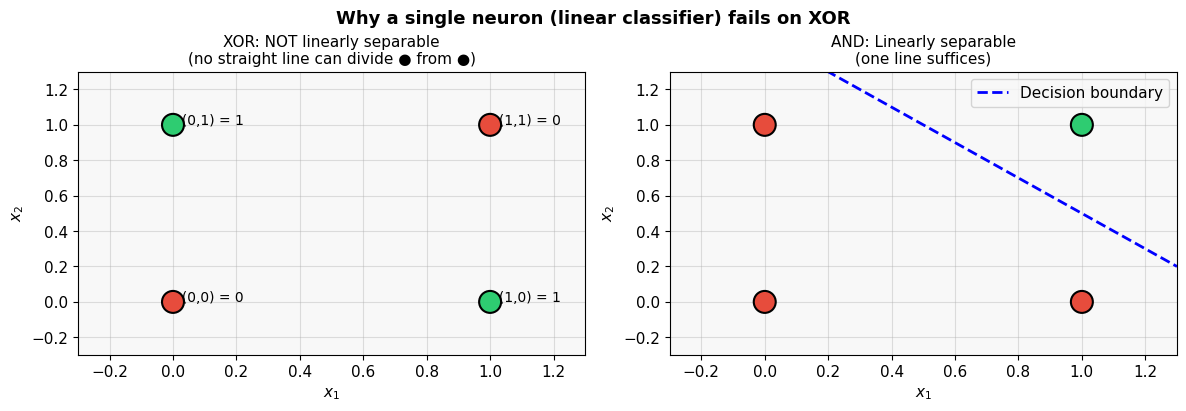

A layer of neurons can solve XOR — we will prove this at the end of this notebook.


In [ ]:
# Visualize why XOR is not linearly separable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# XOR points
X = np.array([[0,0],[0,1],[1,0],[1,1]])
y = np.array([0, 1, 1, 0])
colors = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in y]
labels = ['0 (class 0)', '1 (class 1)', '1 (class 1)', '0 (class 0)']

# Left: XOR — no linear separator
ax = axes[0]
ax.scatter(X[:,0], X[:,1], c=colors, s=250, zorder=5, edgecolors='black', linewidths=1.5)
for i, (xi, label) in enumerate(zip(X, labels)):
    ax.annotate(f'  ({xi[0]},{xi[1]}) = {y[i]}', xi, fontsize=10)
ax.set_title('XOR: NOT linearly separable\n(no straight line can divide ● from ●)', fontsize=11)
ax.set_xlim(-0.3, 1.3); ax.set_ylim(-0.3, 1.3)
ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')

# Right: AND — linearly separable
y_and = np.array([0, 0, 0, 1])
colors_and = ['#e74c3c' if yi == 0 else '#2ecc71' for yi in y_and]
ax2 = axes[1]
ax2.scatter(X[:,0], X[:,1], c=colors_and, s=250, zorder=5, edgecolors='black', linewidths=1.5)
# Draw separating line for AND
xx = np.linspace(-0.3, 1.3, 100)
ax2.plot(xx, 1.5 - xx, 'b--', linewidth=2, label='Decision boundary')
ax2.set_title('AND: Linearly separable\n(one line suffices)', fontsize=11)
ax2.set_xlim(-0.3, 1.3); ax2.set_ylim(-0.3, 1.3)
ax2.set_xlabel('$x_1$'); ax2.set_ylabel('$x_2$')
ax2.legend()

plt.tight_layout()
plt.suptitle('Why a single neuron (linear classifier) fails on XOR', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('01_xor_problem.png', dpi=120, bbox_inches='tight')
plt.show()
print("A layer of neurons can solve XOR — we will prove this at the end of this notebook.")


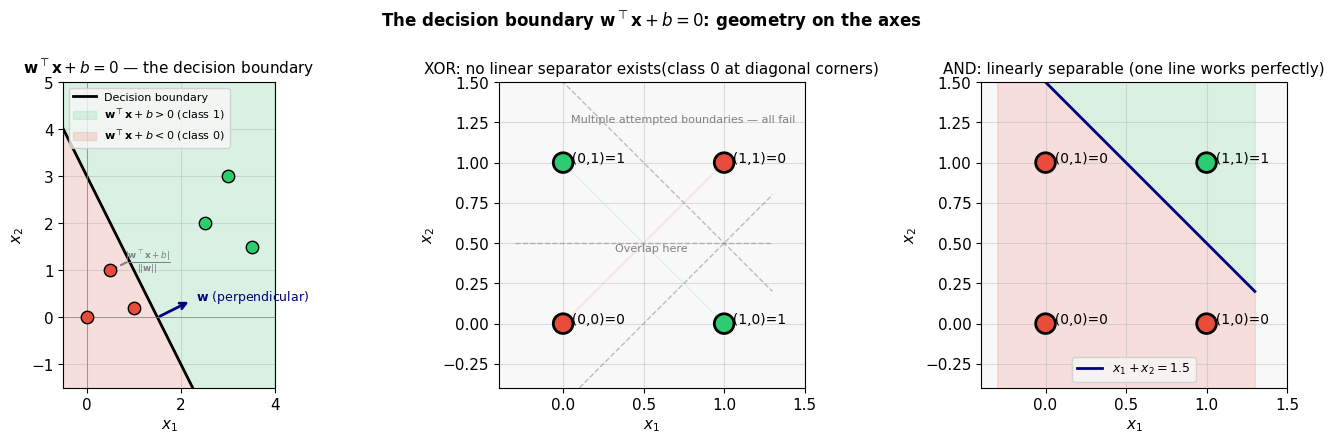

In [ ]:
# VIZ 1: What w^T x + b = 0 looks like — the decision boundary geometry
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Panel 1: The decision boundary and w vector ──────────────────────────────
ax = axes[0]
ax.set_title(r'$\mathbf{w}^\top \mathbf{x} + b = 0$ — the decision boundary', fontsize=11)
w = np.array([2.0, 1.0])
b = -3.0
x1 = np.linspace(-1, 4, 200)
x2_boundary = (-w[0]*x1 - b) / w[1]
ax.plot(x1, x2_boundary, 'k-', lw=2, label='Decision boundary')

# Shade the two half-spaces
ax.fill_between(x1, x2_boundary, 5, alpha=0.15, color='#2ecc71', label=r'$\mathbf{w}^\top\mathbf{x}+b>0$ (class 1)')
ax.fill_between(x1, x2_boundary, -2, alpha=0.15, color='#e74c3c', label=r'$\mathbf{w}^\top\mathbf{x}+b<0$ (class 0)')

# w vector (perpendicular to boundary)
mid_x1 = 1.5
mid_x2 = (-w[0]*mid_x1 - b) / w[1]
wn = w / np.linalg.norm(w) * 0.8
ax.annotate('', xy=(mid_x1+wn[0], mid_x2+wn[1]), xytext=(mid_x1, mid_x2),
            arrowprops=dict(arrowstyle='->', color='navy', lw=2))
ax.text(mid_x1+wn[0]+0.1, mid_x2+wn[1], r'$\mathbf{w}$ (perpendicular)', color='navy', fontsize=9)

# Sample points on each side
pts_pos = np.array([[3,3],[2.5,2],[3.5,1.5]])
pts_neg = np.array([[0,0],[0.5,1],[1,0.2]])
ax.scatter(*pts_pos.T, s=80, color='#2ecc71', edgecolors='black', zorder=5)
ax.scatter(*pts_neg.T, s=80, color='#e74c3c', edgecolors='black', zorder=5)

# Show distance from a point to the boundary = |w^T x + b| / ||w||
pt = np.array([0.5, 1.0])
proj_x1 = (pt[0]*w[0]**2 + pt[1]*w[0]*w[1] - b*w[0]) / np.dot(w,w)
proj_x2 = (proj_x1*w[0] + b) * (-w[0]/w[1]) / w[0] if w[0] != 0 else pt[1]
proj = pt - (np.dot(w, pt) + b) / np.dot(w,w) * w
ax.plot([pt[0], proj[0]], [pt[1], proj[1]], 'gray', lw=1.5, linestyle='--')
ax.text((pt[0]+proj[0])/2+0.1, (pt[1]+proj[1])/2, r'$\frac{|\mathbf{w}^\top\mathbf{x}+b|}{||\mathbf{w}||}$', fontsize=9, color='gray')

ax.set_xlim(-0.5, 4); ax.set_ylim(-1.5, 5)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
ax.legend(fontsize=8, loc='upper left')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal')

# ── Panel 2: XOR — why it fails ──────────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('XOR: no linear separator exists(class 0 at diagonal corners)', fontsize=11)
xor_pts = np.array([[0,0],[0,1],[1,0],[1,1]])
xor_y   = np.array([0, 1, 1, 0])
colors  = ['#e74c3c' if y==0 else '#2ecc71' for y in xor_y]
ax2.scatter(xor_pts[:,0], xor_pts[:,1], c=colors, s=200, edgecolors='black', linewidths=2, zorder=5)
for pt, yi in zip(xor_pts, xor_y):
    ax2.annotate(f'  ({pt[0]},{pt[1]})={yi}', pt, fontsize=10)

# Show several attempted lines — all fail
for slope, intercept, alpha in [(1, -0.5, 0.5),(0, 0.5, 0.5),(-1, 1.5, 0.5)]:
    x_line = np.linspace(-0.3, 1.3, 100)
    y_line = slope*x_line + intercept
    ax2.plot(x_line, y_line, 'gray', lw=1, alpha=alpha, linestyle='--')
ax2.text(0.05, 1.25, 'Multiple attempted boundaries — all fail', fontsize=8, color='gray')

# Convex hulls overlap
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
hull0 = Polygon([[0,0],[1,1],[0.5,0.5]], closed=True, alpha=0.1, color='#e74c3c')
hull1 = Polygon([[0,1],[1,0],[0.5,0.5]], closed=True, alpha=0.1, color='#2ecc71')
ax2.add_patch(hull0); ax2.add_patch(hull1)
ax2.text(0.55, 0.45, 'Overlap here', fontsize=8, ha='center', color='gray')

ax2.set_xlim(-0.4, 1.5); ax2.set_ylim(-0.4, 1.5)
ax2.set_xlabel(r'$x_1$'); ax2.set_ylabel(r'$x_2$')
ax2.set_aspect('equal')

# ── Panel 3: AND — why it works ───────────────────────────────────────────────
ax3 = axes[2]
ax3.set_title('AND: linearly separable (one line works perfectly)', fontsize=11)
and_y = np.array([0, 0, 0, 1])
colors3 = ['#e74c3c' if y==0 else '#2ecc71' for y in and_y]
ax3.scatter(xor_pts[:,0], xor_pts[:,1], c=colors3, s=200, edgecolors='black', linewidths=2, zorder=5)
for pt, yi in zip(xor_pts, and_y):
    ax3.annotate(f'  ({pt[0]},{pt[1]})={yi}', pt, fontsize=10)
x_line = np.linspace(-0.3, 1.3, 100)
ax3.plot(x_line, 1.5 - x_line, 'navy', lw=2, label=r'$x_1 + x_2 = 1.5$')
ax3.fill_between(x_line, 1.5-x_line, 2, alpha=0.15, color='#2ecc71')
ax3.fill_between(x_line, 1.5-x_line, -0.5, alpha=0.15, color='#e74c3c')
ax3.legend(fontsize=9); ax3.set_xlim(-0.4,1.5); ax3.set_ylim(-0.4,1.5)
ax3.set_xlabel(r'$x_1$'); ax3.set_ylabel(r'$x_2$')
ax3.set_aspect('equal')

plt.suptitle(r'The decision boundary $\mathbf{w}^\top\mathbf{x}+b=0$: geometry on the axes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz1_decision_boundary.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 2. The Layer as a Linear Map — Full Matrix Mathematics

### 2.1 Definitions

A layer with $m$ neurons and $n$ inputs defines a function:

$$f: \mathbb{R}^n \rightarrow \mathbb{R}^m, \qquad f(\mathbf{x}) = \phi(W\mathbf{x} + \mathbf{b})$$

where:
- $\mathbf{x} \in \mathbb{R}^n$ — input vector  
- $W \in \mathbb{R}^{m \times n}$ — weight matrix, row $i$ = weights of neuron $i$  
- $\mathbf{b} \in \mathbb{R}^m$ — bias vector  
- $\phi$ — element-wise non-linear activation  
- $\mathbf{y} = f(\mathbf{x}) \in \mathbb{R}^m$ — output vector

### 2.2 The Pre-Activation (Linear Part)

$$\mathbf{z} = W\mathbf{x} + \mathbf{b} = \begin{bmatrix} w_{11} & w_{12} & \cdots & w_{1n} \\ w_{21} & w_{22} & \cdots & w_{2n} \\ \vdots & & \ddots & \vdots \\ w_{m1} & w_{m2} & \cdots & w_{mn} \end{bmatrix} \begin{bmatrix} x_1 \\ x_2 \\ \vdots \\ x_n \end{bmatrix} + \begin{bmatrix} b_1 \\ b_2 \\ \vdots \\ b_m \end{bmatrix}$$

Each element: $z_i = \sum_{j=1}^n w_{ij} x_j + b_i$ — the dot product of neuron $i$'s weights with the input.

### 2.3 Geometric Interpretation — SVD

The weight matrix $W$ can be decomposed via **Singular Value Decomposition**:

$$W = U \Sigma V^\top$$

where $U \in \mathbb{R}^{m \times m}$, $V \in \mathbb{R}^{n \times n}$ are orthogonal (rotation matrices), and $\Sigma$ is diagonal with singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq 0$.

The transformation $W\mathbf{x}$ does three things in sequence:


| Step | Operation | Effect |
|------|-----------|--------|
| $V^\top \mathbf{x}$ | Rotation in input space | Re-orient the input |
| $\Sigma (V^\top \mathbf{x})$ | Scaling | Stretch/compress along principal axes |
| $U \Sigma V^\top \mathbf{x}$ | Rotation in output space | Orient into output representation |

**What singular values tell you:**


- Large $\sigma_i$: that dimension carries a lot of information
- $\sigma_i \approx 0$: the layer has collapsed that direction — **rank deficiency**
- Low effective rank → layer is learning a low-dimensional subspace

### 2.4 Batch Processing

In practice, we process $B$ samples at once. Let $X \in \mathbb{R}^{B \times n}$ (each row is one sample):


$$Z = X W^\top + \mathbf{1}_B \mathbf{b}^\top \in \mathbb{R}^{B \times m}$$

This is a **matrix-matrix product** (BLAS Level-3 GEMM), which runs near peak FLOP efficiency on modern hardware. Processing one sample at a time would be memory-bandwidth bound (BLAS Level-2).



Weight matrix W (4 neurons, 3 inputs):
[[ 1.541 -0.293 -2.179]
 [ 0.568 -1.085 -1.399]
 [ 0.403  0.838 -0.719]
 [-0.403 -0.597  0.182]]

Singular values: [3.2245 1.4537 0.2943]
  → Largest: 3.2245  (most informative direction)
  → Smallest: 0.2943  (least informative direction)

Effective rank estimate: 2 / 3 dimensions are 'active'

Reconstruction error ||W - UΣVᵀ||: 4.66e-07  (should be ≈ 0)


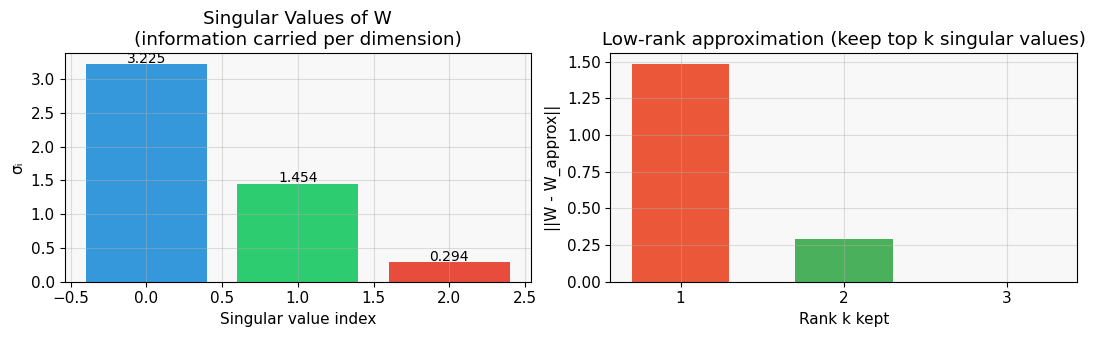

In [12]:
# Visualize the SVD decomposition of a weight matrix
torch.manual_seed(0)
W = torch.randn(4, 3)  # 4 neurons, 3 inputs

U, S, Vt = torch.linalg.svd(W, full_matrices=False)

print("Weight matrix W (4 neurons, 3 inputs):")
print(W.numpy().round(3))
print()
print(f"Singular values: {S.numpy().round(4)}")
print(f"  → Largest: {S[0]:.4f}  (most informative direction)")
print(f"  → Smallest: {S[-1]:.4f}  (least informative direction)")
print()
print(f"Effective rank estimate: {(S > 0.1 * S[0]).sum().item()} / {len(S)} dimensions are 'active'")
print()

# Reconstruct and verify
W_reconstructed = U @ torch.diag(S) @ Vt
print(f"Reconstruction error ||W - UΣVᵀ||: {(W - W_reconstructed).norm():.2e}  (should be ≈ 0)")

# Visualize singular values
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(range(len(S)), S.numpy(), color=['#3498db','#2ecc71','#e74c3c'][:len(S)])
axes[0].set_title('Singular Values of W\n(information carried per dimension)')
axes[0].set_xlabel('Singular value index')
axes[0].set_ylabel('σᵢ')
for i, s in enumerate(S):
    axes[0].text(i, s.item()+0.02, f'{s.item():.3f}', ha='center', fontsize=10)

# Show what happens if we low-rank approximate W
axes[1].set_title('Low-rank approximation (keep top k singular values)')
for k in range(1, len(S)+1):
    W_approx = U[:, :k] @ torch.diag(S[:k]) @ Vt[:k, :]
    err = (W - W_approx).norm().item()
    axes[1].bar(k, err, color=plt.cm.RdYlGn_r(err / W.norm().item() * 2), width=0.6)
axes[1].set_xlabel('Rank k kept')
axes[1].set_ylabel('||W - W_approx||')
axes[1].set_xticks(range(1, len(S)+1))

plt.tight_layout()
plt.savefig('02_svd_layer.png', dpi=120, bbox_inches='tight')
plt.show()


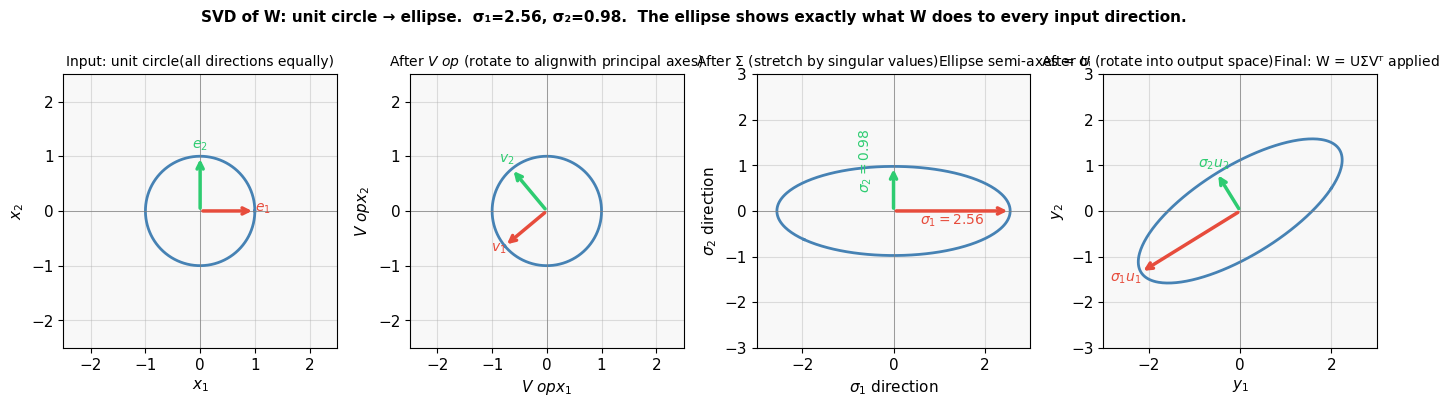

Singular values: σ₁=2.558, σ₂=0.977
σ₁/σ₂ = 2.62  →  the ellipse is 2.6x longer in the σ₁ direction


In [16]:
# VIZ 2: SVD geometric interpretation — what W does to input space
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

np.random.seed(0)
W = np.array([[2.0, 1.0], [0.5, 1.5]])
U, S, Vt = np.linalg.svd(W)
V = Vt.T

# Unit circle
theta = np.linspace(0, 2*np.pi, 300)
circle = np.stack([np.cos(theta), np.sin(theta)])  # (2, 300)

def draw_axes_arrows(ax, origin, vecs, colors, labels, scale=1.0):
    for v, c, l in zip(vecs, colors, labels):
        ax.annotate('', xy=origin+v*scale, xytext=origin,
                    arrowprops=dict(arrowstyle='->', color=c, lw=2.5))
        ax.text(*(origin+v*scale*1.15), l, color=c, fontsize=10, ha='center', fontweight='bold')

# Step 0: original circle
ax = axes[0]
ax.plot(*circle, 'steelblue', lw=2)
draw_axes_arrows(ax, np.zeros(2), [np.array([1,0]), np.array([0,1])],
                 ['#e74c3c','#2ecc71'], [r'$e_1$', r'$e_2$'])
ax.set_title('Input: unit circle(all directions equally)', fontsize=10)
ax.set_xlim(-2.5,2.5); ax.set_ylim(-2.5,2.5); ax.set_aspect('equal')
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')

# Step 1: after V^T — rotation
rotated = Vt @ circle
ax = axes[1]
ax.plot(*rotated, 'steelblue', lw=2)
draw_axes_arrows(ax, np.zeros(2), [Vt[:,0], Vt[:,1]],
                 ['#e74c3c','#2ecc71'], [r'$v_1$', r'$v_2$'])
ax.set_title(r'After $V^\top$ (rotate to align' + 'with principal axes)', fontsize=10)
ax.set_xlim(-2.5,2.5); ax.set_ylim(-2.5,2.5); ax.set_aspect('equal')
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.set_xlabel(r"$V^\top x_1$"); ax.set_ylabel(r"$V^\top x_2$")

# Step 2: after Sigma — scale (the ellipse)
scaled = np.diag(S) @ rotated
ax = axes[2]
ax.plot(*scaled, 'steelblue', lw=2)
ax.annotate('', xy=(S[0],0), xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2.5))
ax.annotate('', xy=(0,S[1]), xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2.5))
ax.text(S[0]/2, -0.3, fr'$\sigma_1={S[0]:.2f}$', color='#e74c3c', fontsize=10, ha='center')
ax.text(-0.6, S[1]/2, fr'$\sigma_2={S[1]:.2f}$', color='#2ecc71', fontsize=10, ha='center', rotation=90)
ax.set_title(r'After $\Sigma$ (stretch by singular values)' + 'Ellipse semi-axes = σᵢ', fontsize=10)
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal')
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.set_xlabel(r"$\sigma_1$ direction"); ax.set_ylabel(r"$\sigma_2$ direction")

# Step 3: after U — rotate to output space (= full W applied)
final = U @ scaled
ax = axes[3]
ax.plot(*final, 'steelblue', lw=2)
draw_axes_arrows(ax, np.zeros(2), [U[:,0]*S[0], U[:,1]*S[1]],
                 ['#e74c3c','#2ecc71'], [r'$\sigma_1 u_1$', r'$\sigma_2 u_2$'])
ax.set_title(r'After $U$ (rotate into output space)' + 'Final: W = UΣVᵀ applied', fontsize=10)
ax.set_xlim(-3,3); ax.set_ylim(-3,3); ax.set_aspect('equal')
ax.axhline(0,color='gray',lw=0.5); ax.axvline(0,color='gray',lw=0.5)
ax.set_xlabel(r'$y_1$'); ax.set_ylabel(r'$y_2$')

plt.suptitle(fr'SVD of W: unit circle → ellipse.  σ₁={S[0]:.2f}, σ₂={S[1]:.2f}.  '
             fr'The ellipse shows exactly what W does to every input direction.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_svd_geometry.png', dpi=130, bbox_inches='tight')
plt.show()

print(f"Singular values: σ₁={S[0]:.3f}, σ₂={S[1]:.3f}")
print(f"σ₁/σ₂ = {S[0]/S[1]:.2f}  →  the ellipse is {S[0]/S[1]:.1f}x longer in the σ₁ direction")


---
## 3. Weight Initialization — The Variance Propagation Problem

### 3.1 Why initialization matters

Suppose we stack $L$ layers. At initialization, if variance is not carefully controlled:


$$\text{Var}(\mathbf{z}^{(l)}) = \left(n \cdot \sigma_w^2\right)^l \cdot \text{Var}(\mathbf{x})$$

- If $n \cdot \sigma_w^2 > 1$: activations **explode** as $l$ increases → gradients explode
- If $n \cdot \sigma_w^2 < 1$: activations **vanish** as $l$ increases → gradients vanish

We need $n \cdot \sigma_w^2 = 1$.

### 3.2 LeCun Initialization (1998)


For stable forward propagation:

$$\text{Var}(y_i) = n \cdot \sigma_w^2 \cdot \text{Var}(x_j) \implies \sigma_w^2 = \frac{1}{n_{\text{in}}}$$

$$w \sim \mathcal{N}\!\left(0,\, \frac{1}{n_{\text{in}}}\right)$$

### 3.3 Xavier / Glorot Initialization (2010)


Glorot considered *both* forward and backward pass. Gradient variance must also be stable:

$$\text{Var}\!\left(\frac{\partial \mathcal{L}}{\partial \mathbf{x}^{(l)}}\right) = n_{\text{out}} \cdot \sigma_w^2 \cdot \text{Var}\!\left(\frac{\partial \mathcal{L}}{\partial \mathbf{z}^{(l)}}\right)$$

Harmonic compromise between forward ($1/n_{\text{in}}$) and backward ($1/n_{\text{out}}$) requirements:

$$\boxed{\sigma_w^2 = \frac{2}{n_{\text{in}} + n_{\text{out}}}}$$

Uniform variant:

$$w \sim U\!\left[-\frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}},\ \frac{\sqrt{6}}{\sqrt{n_{\text{in}} + n_{\text{out}}}}\right]$$

### 3.4 He / Kaiming Initialization (2015)


Glorot assumes linear activations. **ReLU zeroes out ~50% of neurons**, effectively halving the variance:

$$\text{Var}(\text{ReLU}(z)) = \frac{1}{2} \text{Var}(z) \quad (\text{for symmetric } z)$$

He et al. corrected for this:


$$\boxed{\sigma_w^2 = \frac{2}{n_{\text{in}}}}$$

This is what PyTorch uses by default for `nn.Linear` with ReLU.

### 3.5 What changes when you use wrong initialization?

| Initialization | With sigmoid | With ReLU |
|---------------|-------------|-----------|
| Too small ($\sigma_w \ll$) | Gradients vanish; network learns nothing | Same — dead at start |
| Too large ($\sigma_w \gg$) | Saturated neurons; gradients ≈ 0 | Exploding activations |
| LeCun | Good for sigmoid/tanh | Slightly suboptimal for ReLU |
| Xavier | Best for sigmoid/tanh | Suboptimal for ReLU |
| He | Suboptimal for sigmoid | **Best for ReLU** |


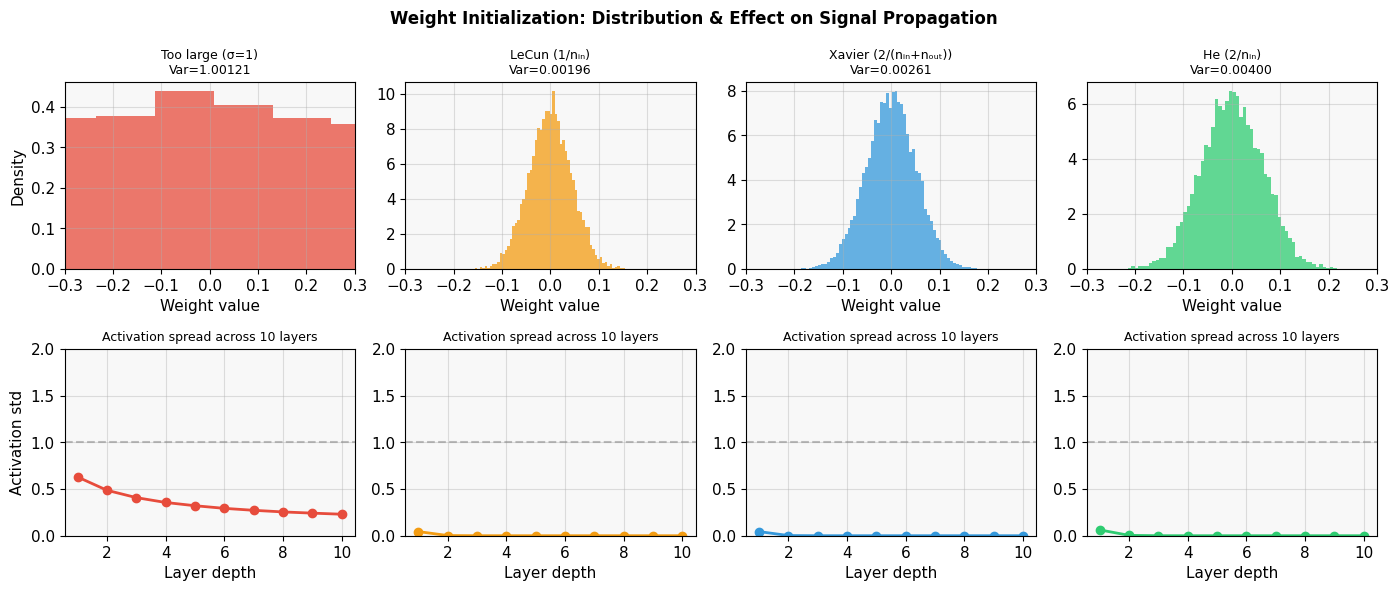


Key insight: Xavier/He keep activation variance ≈ 1 across layers.
Too-large init → saturated sigmoid → vanishing gradients → nothing learned.


In [17]:
def init_weights(method, n_in, n_out, n_samples=10000):
    """Generate weight samples using different initialization strategies."""
    if method == 'zeros':
        return torch.zeros(n_samples)
    elif method == 'too_large':
        return torch.randn(n_samples) * 1.0
    elif method == 'lecun':
        return torch.randn(n_samples) * np.sqrt(1.0 / n_in)
    elif method == 'xavier':
        return torch.randn(n_samples) * np.sqrt(2.0 / (n_in + n_out))
    elif method == 'he':
        return torch.randn(n_samples) * np.sqrt(2.0 / n_in)

n_in, n_out = 512, 256
methods = ['too_large', 'lecun', 'xavier', 'he']
colors  = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
labels  = ['Too large (σ=1)', 'LeCun (1/nᵢₙ)', 'Xavier (2/(nᵢₙ+nₒᵤₜ))', 'He (2/nᵢₙ)']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for col, (method, color, label) in enumerate(zip(methods, colors, labels)):
    w = init_weights(method, n_in, n_out)

    # Simulate signal after 10 layers (forward pass approximation)
    x = torch.randn(1000, n_in)
    activations_per_layer = []
    for layer in range(10):
        W = init_weights(method, n_in, n_in, n_in * n_in).reshape(n_in, n_in)
        x = torch.tanh(x @ W.T / np.sqrt(n_in))   # normalize for fair matmul
        activations_per_layer.append(x.std().item())

    # Top row: weight distribution
    axes[0, col].hist(w.numpy(), bins=60, color=color, alpha=0.75, density=True)
    axes[0, col].set_title(f'{label}\nVar={w.var():.5f}', fontsize=9)
    axes[0, col].set_xlim(-0.3, 0.3)
    axes[0, col].set_xlabel('Weight value')
    if col == 0: axes[0, col].set_ylabel('Density')

    # Bottom row: activation std per layer
    axes[1, col].plot(range(1, 11), activations_per_layer, 'o-', color=color, linewidth=2)
    axes[1, col].axhline(1.0, color='gray', linestyle='--', alpha=0.5, label='ideal std=1')
    axes[1, col].set_ylim(0, 2)
    axes[1, col].set_xlabel('Layer depth')
    if col == 0: axes[1, col].set_ylabel('Activation std')
    axes[1, col].set_title('Activation spread across 10 layers', fontsize=9)

plt.suptitle('Weight Initialization: Distribution & Effect on Signal Propagation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('03_weight_init.png', dpi=120, bbox_inches='tight')
plt.show()
print()
print("Key insight: Xavier/He keep activation variance ≈ 1 across layers.")
print("Too-large init → saturated sigmoid → vanishing gradients → nothing learned.")


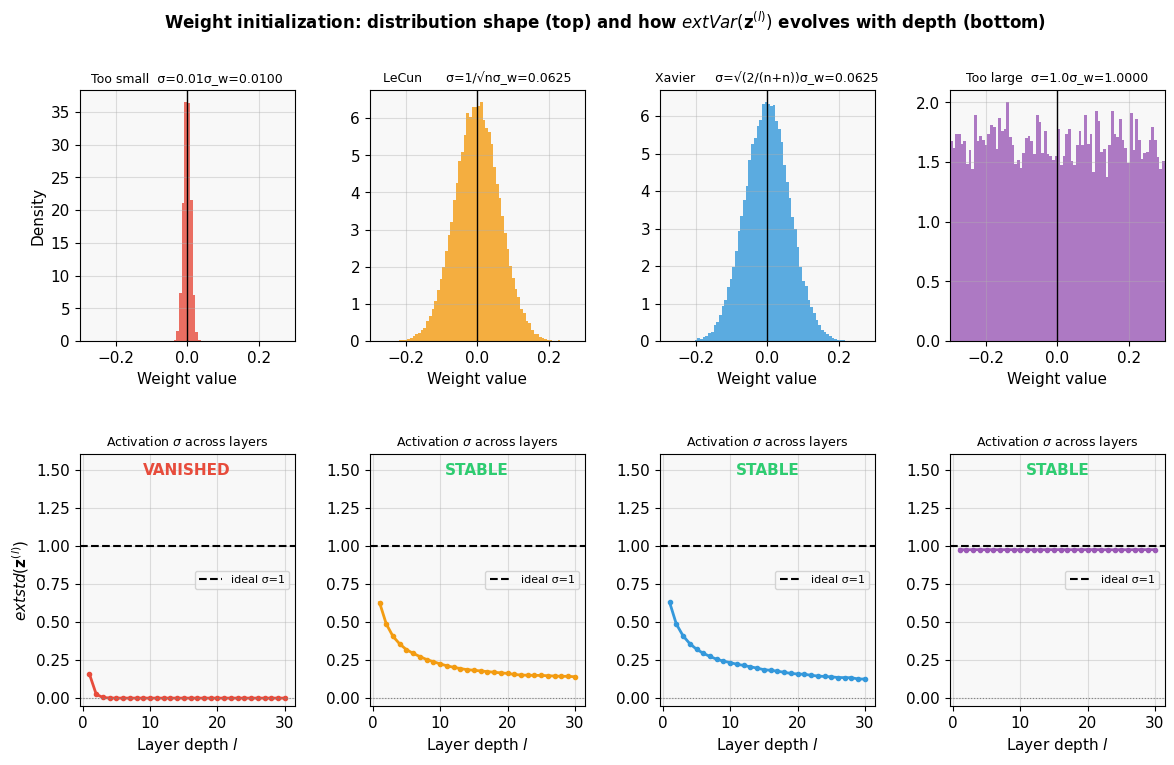

In [19]:
# VIZ 3: Weight initialization — distribution shape AND signal propagation depth
import numpy as np
import matplotlib.pyplot as plt
import torch

np.random.seed(0); torch.manual_seed(0)
n = 256

def propagate(std, n_layers=30, n=256, B=512):
    x = torch.randn(B, n)
    stds = []
    for _ in range(n_layers):
        W = torch.randn(n, n) * std
        x = torch.tanh(x @ W)
        stds.append(x.std().item())
    return stds

configs = [
    ('Too small  σ=0.01', 0.01,  '#e74c3c'),
    ('LeCun      σ=1/√n', 1/np.sqrt(n), '#f39c12'),
    ('Xavier     σ=√(2/(n+n))', np.sqrt(2/(n+n)), '#3498db'),
    ('Too large  σ=1.0',  1.0,  '#9b59b6'),
]

fig = plt.figure(figsize=(14, 8))
gs  = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.35)

for col, (label, std, color) in enumerate(configs):
    stds_depth = propagate(std)

    # Top row: weight distribution
    ax_top = fig.add_subplot(gs[0, col])
    w_samples = np.random.randn(50000) * std
    ax_top.hist(w_samples, bins=80, color=color, alpha=0.8, density=True, range=(-0.3,0.3))
    ax_top.axvline(0, color='black', lw=1)
    ax_top.set_title(label + f'σ_w={std:.4f}', fontsize=9)
    ax_top.set_xlabel('Weight value')
    if col == 0: ax_top.set_ylabel('Density')
    ax_top.set_xlim(-0.3, 0.3)

    # Bottom row: activation std per layer
    ax_bot = fig.add_subplot(gs[1, col])
    ax_bot.plot(range(1, len(stds_depth)+1), stds_depth, 'o-',
                color=color, lw=2, ms=3)
    ax_bot.axhline(1.0, color='black', lw=1.5, linestyle='--', label='ideal σ=1')
    ax_bot.axhline(0.0, color='gray',  lw=0.8, linestyle=':')
    ax_bot.set_ylim(-0.05, 1.6)
    ax_bot.set_xlabel('Layer depth $l$')
    if col == 0: ax_bot.set_ylabel(r'$\text{std}(\mathbf{z}^{(l)})$')
    ax_bot.set_title(r'Activation $\sigma$ across layers', fontsize=9)
    ax_bot.legend(fontsize=8)

    # Annotate what happens
    final_std = stds_depth[-1]
    fate = 'VANISHED' if final_std < 0.05 else ('EXPLODED' if final_std > 1.4 else 'STABLE')
    fc   = '#e74c3c' if fate != 'STABLE' else '#2ecc71'
    ax_bot.text(0.5, 0.92, fate, transform=ax_bot.transAxes,
                fontsize=11, fontweight='bold', ha='center', color=fc)

plt.suptitle(r'Weight initialization: distribution shape (top) and how $\text{Var}(\mathbf{z}^{(l)})$ evolves with depth (bottom)',
             fontsize=12, fontweight='bold')
plt.savefig('viz3_init_depth.png', dpi=130, bbox_inches='tight')
plt.show()


<>:47: SyntaxWarning: invalid escape sequence '\s'
<>:47: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_6626/916314180.py:47: SyntaxWarning: invalid escape sequence '\s'
  ax3.set_title('He vs LeCun: He uses $\sqrt{2}\times$ larger stdto compensate for ReLU halving variance', fontsize=10)


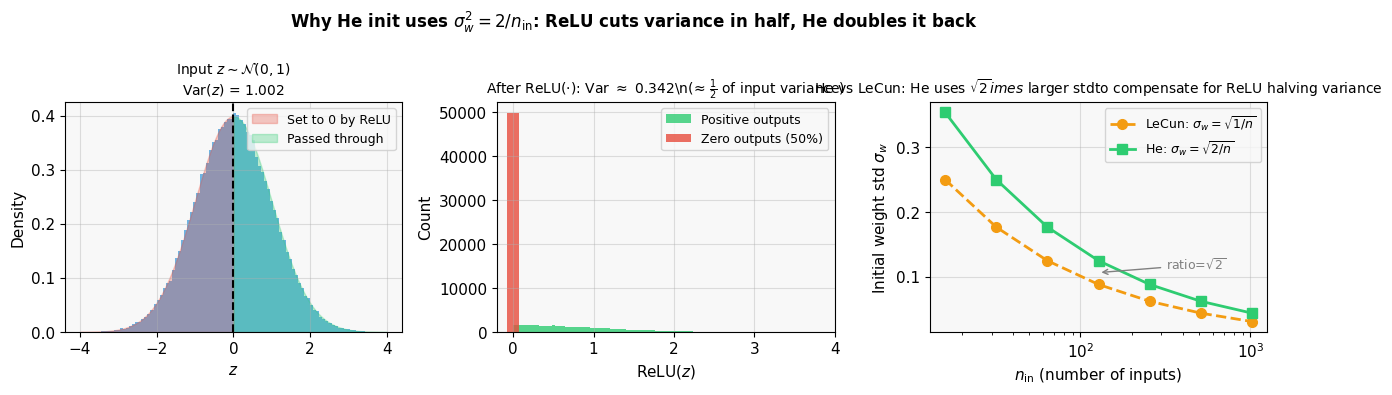

In [22]:
# VIZ 4: Why ReLU halves the variance — and what He init corrects
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
np.random.seed(42)

z_samples = np.random.randn(100000)  # z ~ N(0,1) before ReLU
relu_out  = np.maximum(0, z_samples)

# Panel 1: input distribution
ax = axes[0]
ax.hist(z_samples, bins=100, color='#3498db', alpha=0.7, density=True, range=(-4,4))
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_title(fr'Input $z \sim \mathcal{{N}}(0,1)$' + '\n' +
             fr'Var$(z)$ = {np.var(z_samples):.3f}', fontsize=10)
ax.set_xlabel('$z$'); ax.set_ylabel('Density')
ax.fill_between(np.linspace(-4,0,100),
                [0]*100, [1/np.sqrt(2*np.pi)*np.exp(-x**2/2) for x in np.linspace(-4,0,100)],
                alpha=0.3, color='#e74c3c', label='Set to 0 by ReLU')
ax.fill_between(np.linspace(0,4,100),
                [0]*100, [1/np.sqrt(2*np.pi)*np.exp(-x**2/2) for x in np.linspace(0,4,100)],
                alpha=0.3, color='#2ecc71', label='Passed through')
ax.legend(fontsize=9)

# Panel 2: output distribution after ReLU
ax2 = axes[1]
ax2.hist(relu_out[relu_out>0], bins=100, color='#2ecc71', alpha=0.8, density=False,
         range=(0,4), label='Positive outputs')
ax2.bar(0, (relu_out==0).sum(), width=0.15, color='#e74c3c', alpha=0.8, label=f'Zero outputs ({(relu_out==0).mean()*100:.0f}%)')
ax2.set_title(fr'After ReLU$(\cdot)$: Var $\approx$ {np.var(relu_out):.3f}' + r'\n(≈ $\frac{1}{2}$ of input variance)', fontsize=10)
ax2.set_xlabel('ReLU$(z)$')
ax2.set_ylabel('Count')
ax2.legend(fontsize=9)
ax2.set_xlim(-0.2, 4)

# Panel 3: He init compensates
ax3 = axes[2]
n_in_values = [16, 32, 64, 128, 256, 512, 1024]
std_lecun = [np.sqrt(1/n) for n in n_in_values]
std_he    = [np.sqrt(2/n) for n in n_in_values]

ax3.semilogx(n_in_values, std_lecun, 'o--', color='#f39c12', lw=2, ms=7, label=r'LeCun: $\sigma_w=\sqrt{1/n}$')
ax3.semilogx(n_in_values, std_he,    's-',  color='#2ecc71', lw=2, ms=7, label=r'He: $\sigma_w=\sqrt{2/n}$')
ax3.set_xlabel(r'$n_{\mathrm{in}}$ (number of inputs)')
ax3.set_ylabel(r'Initial weight std $\sigma_w$')
ax3.set_title('He vs LeCun: He uses $\sqrt{2}\times$ larger stdto compensate for ReLU halving variance', fontsize=10)
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.4)

# Annotate ratio
for n, sl, sh in zip(n_in_values, std_lecun, std_he):
    if n == 128:
        ax3.annotate(r'ratio=$\sqrt{2}$', xy=(n, (sl+sh)/2),
                     xytext=(n*2.5, (sl+sh)/2+0.005),
                     arrowprops=dict(arrowstyle='->', color='gray'),
                     fontsize=9, color='gray')

plt.suptitle(r'Why He init uses $\sigma_w^2=2/n_{\mathrm{in}}$: ReLU cuts variance in half, He doubles it back',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz4_relu_variance.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 4. Activation Functions — Deep Mathematical Analysis

### 4.1 Why activation functions must be non-linear

Without non-linearity, $L$ stacked layers reduce to a single matrix multiplication:

$$W_L(W_{L-1}(\cdots W_1 \mathbf{x})) = \underbrace{(W_L \cdots W_1)}_{\text{single matrix}} \mathbf{x}$$

This is still just a linear map — you have gained *nothing* from depth.


### 4.2 Sigmoid

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \qquad \sigma'(z) = \sigma(z)(1 - \sigma(z))$$

**Maximum gradient:** $\sigma'(0) = 0.25$.  


**Vanishing gradient problem:** For $|z| > 4$, $\sigma'(z) < 0.005$. Gradients through multiple sigmoid layers multiply small numbers → vanish.

**Why it was popular:** Output in $(0,1)$ — looks like a probability. McCulloch-Pitts neuron inspiration.

### 4.3 Tanh

$$\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}} = 2\sigma(2z) - 1, \qquad \tanh'(z) = 1 - \tanh^2(z)$$

Maximum gradient: $\tanh'(0) = 1$ — better than sigmoid.  
Zero-centered: mean activation $\approx 0$ → better gradient flow than sigmoid.  
Still saturates for large $|z|$.

### 4.4 ReLU — Rectified Linear Unit


$$\text{ReLU}(z) = \max(0, z), \qquad \text{ReLU}'(z) = \mathbb{1}[z > 0]$$

**Why it works:**
- **No saturation** for $z > 0$: gradient is always 1 (or 0)
- **Sparse activation:** ~50% of neurons are zero → efficient representations
- **Computationally cheap:** just a threshold
- **Biologically plausible:** neurons either fire or don't

**Dying ReLU problem:** If a neuron always outputs 0 (weights push $z < 0$ for all inputs), its gradient is permanently 0 — it never recovers. Caused by large learning rates or bad initialization.


### 4.5 Leaky ReLU & ELU


**Leaky ReLU** (Maas et al., 2013):
$$\text{LeakyReLU}(z) = \begin{cases} z & z > 0 \\ \alpha z & z \leq 0 \end{cases}, \quad \alpha \approx 0.01$$

Fixes dying ReLU — negative region still has non-zero gradient.

**ELU:**
$$\text{ELU}(z) = \begin{cases} z & z > 0 \\ \alpha(e^z - 1) & z \leq 0 \end{cases}$$

Mean activation closer to 0 than ReLU → faster learning. Smooth everywhere.

### 4.6 GeLU — Used in Transformers (GPT, BERT)


$$\text{GeLU}(z) = z \cdot \Phi(z) \approx 0.5z\left(1 + \tanh\!\left[\sqrt{\frac{2}{\pi}}(z + 0.044715 z^3)\right]\right)$$

where $\Phi$ is the CDF of the standard normal. GeLU is stochastic: it weights each input $z$ by the probability that $z$ is greater than a random standard normal. Used in BERT, GPT-2/3, and most modern Transformers.


### 4.7 What changes when you change the activation?

| Effect | Sigmoid | Tanh | ReLU | ELU | GeLU |
|--------|---------|------|------|-----|------|
| Gradient saturation | Yes ($>4$) | Yes ($>3$) | No (for $z>0$) | No | No |
| Dead neurons | No | No | Yes | No | No |
| Zero-centered output | No | Yes | No | ~Yes | ~Yes |
| Smooth | Yes | Yes | No (kink at 0) | Yes | Yes |
| Used in Transformers | No | LSTM gates | FFN (older) | No | **Yes** |


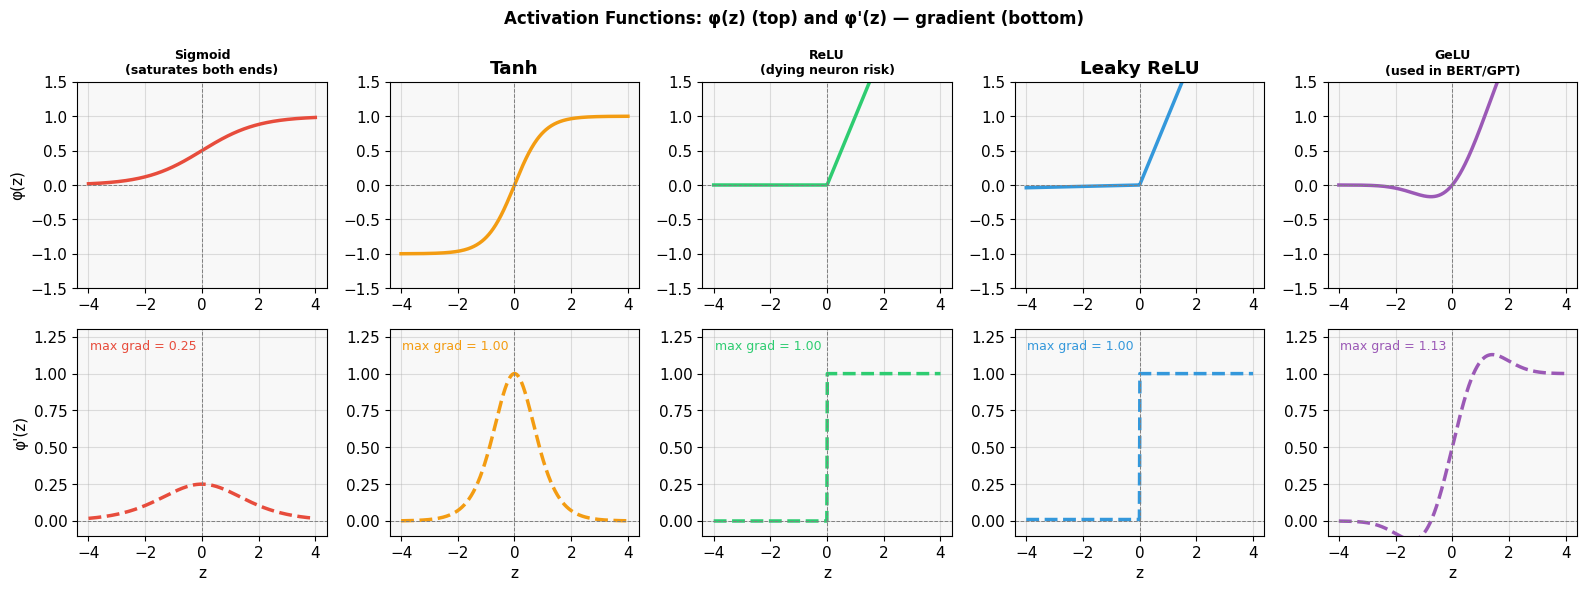


--- Dying ReLU Demo ---
If z < 0 for ALL training samples, ReLU gradient = 0 permanently.
This neuron is dead — it will never update its weights.
z values: [-3.  -1.5 -0.5 -2. ]
ReLU outputs: [0. 0. 0. 0.]  ← all zero
ReLU gradients: [0. 0. 0. 0.]  ← all zero, no learning possible


In [23]:
z = torch.linspace(-4, 4, 500)

def sigmoid(z):   return 1 / (1 + torch.exp(-z))
def d_sigmoid(z): s = sigmoid(z); return s * (1 - s)
def tanh_(z):     return torch.tanh(z)
def d_tanh(z):    return 1 - torch.tanh(z)**2
def relu(z):      return torch.clamp(z, min=0)
def d_relu(z):    return (z > 0).float()
def leaky(z, a=0.01): return torch.where(z > 0, z, a * z)
def d_leaky(z, a=0.01): return torch.where(z > 0, torch.ones_like(z), torch.full_like(z, a))
def gelu(z):      return z * 0.5 * (1 + torch.erf(z / np.sqrt(2)))
def d_gelu(z):    phi = 0.5*(1+torch.erf(z/np.sqrt(2))); dphi = torch.exp(-0.5*z**2)/np.sqrt(2*np.pi); return phi + z*dphi

activations = [
    ('Sigmoid', sigmoid, d_sigmoid, '#e74c3c'),
    ('Tanh',    tanh_,   d_tanh,    '#f39c12'),
    ('ReLU',    relu,    d_relu,    '#2ecc71'),
    ('Leaky ReLU', leaky, d_leaky,  '#3498db'),
    ('GeLU',    gelu,    d_gelu,    '#9b59b6'),
]

fig, axes = plt.subplots(2, 5, figsize=(16, 6))

for col, (name, fn, dfn, color) in enumerate(activations):
    y  = fn(z).detach().numpy()
    dy = dfn(z).detach().numpy()

    # Top: activation
    axes[0, col].plot(z.numpy(), y, color=color, linewidth=2.5)
    axes[0, col].axhline(0, color='gray', linewidth=0.7, linestyle='--')
    axes[0, col].axvline(0, color='gray', linewidth=0.7, linestyle='--')
    axes[0, col].set_title(name, fontweight='bold')
    axes[0, col].set_ylim(-1.5, 1.5)
    if col == 0: axes[0, col].set_ylabel('φ(z)')

    # Bottom: gradient
    axes[1, col].plot(z.numpy(), dy, color=color, linewidth=2.5, linestyle='--')
    axes[1, col].axhline(0, color='gray', linewidth=0.7, linestyle='--')
    axes[1, col].axvline(0, color='gray', linewidth=0.7, linestyle='--')
    axes[1, col].set_ylim(-0.1, 1.3)
    axes[1, col].set_xlabel('z')
    if col == 0: axes[1, col].set_ylabel("φ'(z)")

    # Annotate max gradient
    max_g = dy.max()
    axes[1, col].text(0.05, 0.95, f'max grad = {max_g:.2f}',
                      transform=axes[1, col].transAxes, fontsize=9,
                      verticalalignment='top', color=color)

axes[0, 0].set_title('Sigmoid\n(saturates both ends)', fontsize=9, fontweight='bold')
axes[0, 2].set_title('ReLU\n(dying neuron risk)', fontsize=9, fontweight='bold')
axes[0, 4].set_title('GeLU\n(used in BERT/GPT)', fontsize=9, fontweight='bold')

plt.suptitle('Activation Functions: φ(z) (top) and φ\'(z) — gradient (bottom)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('04_activations.png', dpi=120, bbox_inches='tight')
plt.show()

# Demonstrate dying ReLU
print("\n--- Dying ReLU Demo ---")
print("If z < 0 for ALL training samples, ReLU gradient = 0 permanently.")
print("This neuron is dead — it will never update its weights.")
dead_z = torch.tensor([-3.0, -1.5, -0.5, -2.0])
print(f"z values: {dead_z.numpy()}")
print(f"ReLU outputs: {relu(dead_z).numpy()}  ← all zero")
print(f"ReLU gradients: {d_relu(dead_z).numpy()}  ← all zero, no learning possible")


/tmp/ipykernel_6626/1669747069.py:74: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  grad_single = float(dfn(np.array([z_val])))


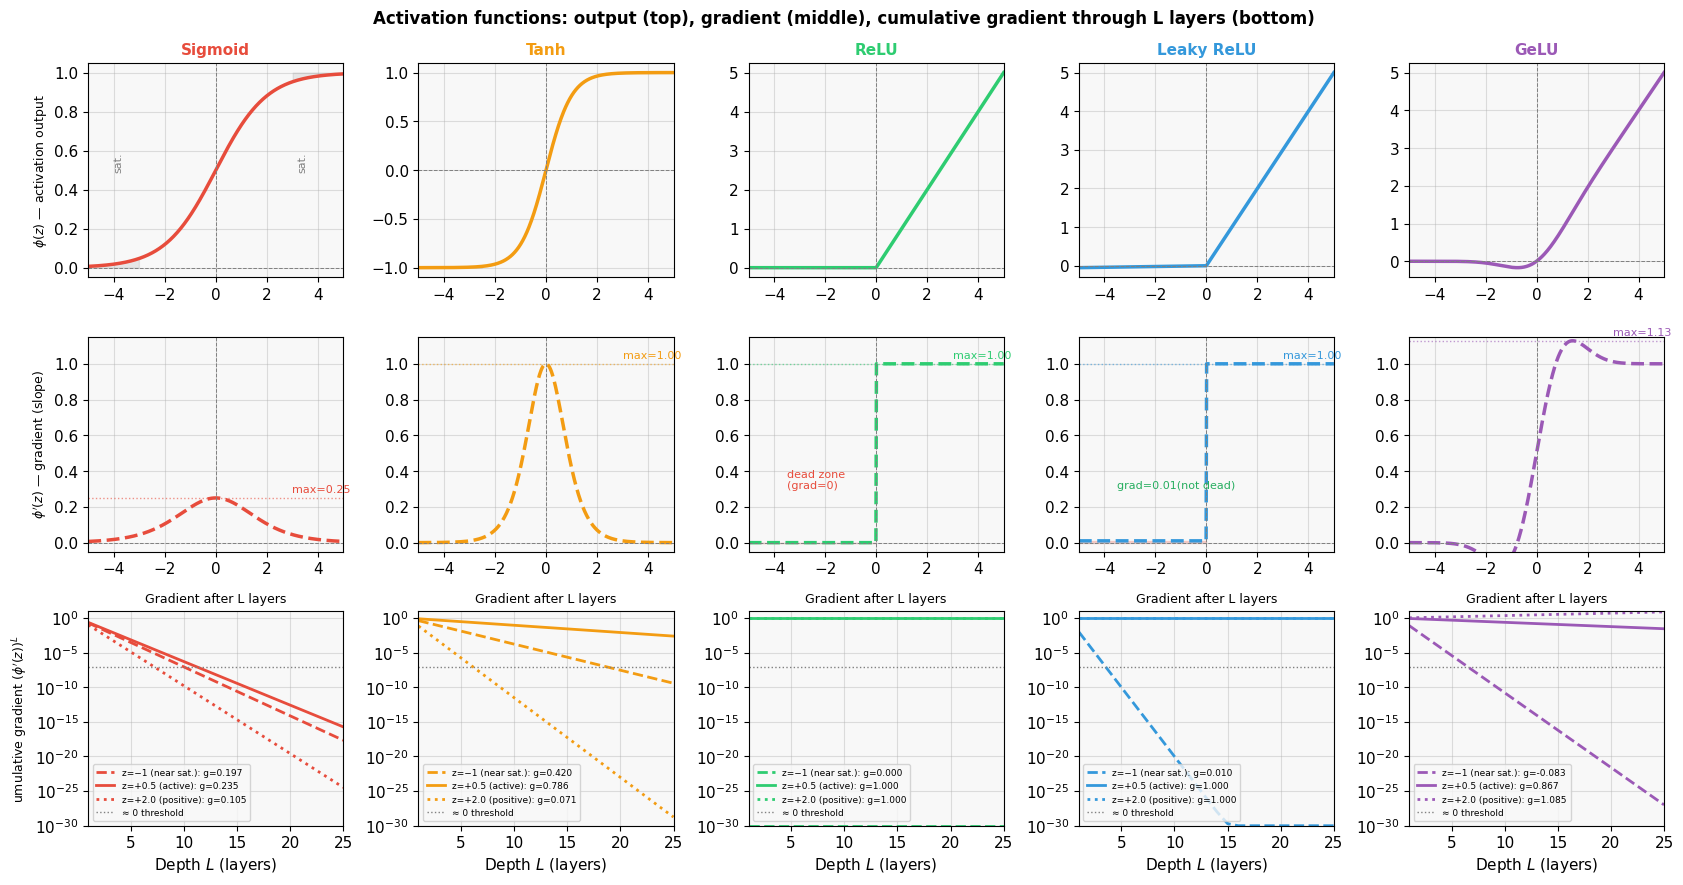

In [27]:
# VIZ 5: Activation functions — saturation zones, gradient magnitude, dying ReLU
import numpy as np
import matplotlib.pyplot as plt
import torch

z = np.linspace(-5, 5, 500)

def sigmoid(z): return 1/(1+np.exp(-z))
def d_sigmoid(z): s=sigmoid(z); return s*(1-s)
def tanh_(z):  return np.tanh(z)
def d_tanh(z): return 1-np.tanh(z)**2
def relu(z):   return np.maximum(0,z)
def d_relu(z): return (z>0).astype(float)
def lrelu(z,a=0.01): return np.where(z>0,z,a*z)
def d_lrelu(z,a=0.01): return np.where(z>0,1,a)
def gelu(z):   return z*0.5*(1+np.vectorize(lambda x: float(torch.erf(torch.tensor(x/np.sqrt(2)))))(z))
def d_gelu(z): phi=0.5*(1+np.vectorize(lambda x: float(torch.erf(torch.tensor(x/np.sqrt(2)))))(z)); dphi=np.exp(-0.5*z**2)/np.sqrt(2*np.pi); return phi+z*dphi

acts = [
    ('Sigmoid',     sigmoid,  d_sigmoid, '#e74c3c'),
    ('Tanh',        tanh_,    d_tanh,    '#f39c12'),
    ('ReLU',        relu,     d_relu,    '#2ecc71'),
    ('Leaky ReLU',  lrelu,    d_lrelu,   '#3498db'),
    ('GeLU',        gelu,     d_gelu,    '#9b59b6'),
]

fig, axes = plt.subplots(3, 5, figsize=(17, 9))

for col, (name, fn, dfn, color) in enumerate(acts):
    y  = fn(z)
    dy = dfn(z)

    # Row 0: activation function
    ax = axes[0,col]
    ax.plot(z, y, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.7, linestyle='--')
    ax.axvline(0, color='gray', lw=0.7, linestyle='--')
    ax.set_title(name, fontsize=11, fontweight='bold', color=color)
    ax.set_ylabel(r'$\phi(z)$') if col==0 else None
    ax.set_xlim(-5,5)
    # Shade saturation regions
    if name == 'Sigmoid':
        ax.fill_between(z, y, 0, where=z<-3, alpha=0.15, color='gray')
        ax.fill_between(z, y, 1, where=z>3,  alpha=0.15, color='gray')
        ax.text(-4, 0.5, 'sat.', fontsize=8, color='gray', rotation=90)
        ax.text(3.2, 0.5, 'sat.', fontsize=8, color='gray', rotation=90)
    if name == 'Tanh':
        ax.fill_between(z, y, -1, where=z<-2.5, alpha=0.15, color='gray')
        ax.fill_between(z, y, 1,  where=z>2.5,  alpha=0.15, color='gray')

    # Row 1: gradient
    ax2 = axes[1,col]
    ax2.plot(z, dy, color=color, lw=2.5, linestyle='--')
    ax2.axhline(0, color='gray', lw=0.7, linestyle='--')
    ax2.axvline(0, color='gray', lw=0.7, linestyle='--')
    ax2.set_ylabel(r"$\phi'(z)$") if col==0 else None
    ax2.set_ylim(-0.05, 1.15)
    ax2.set_xlim(-5,5)
    max_g = dy.max()
    ax2.axhline(max_g, color=color, lw=1, linestyle=':', alpha=0.6)
    ax2.text(3, max_g+0.03, f'max={max_g:.2f}', fontsize=8, color=color)
    # ReLU dead zone
    if name in ('ReLU', 'Leaky ReLU'):
        ax2.fill_between(z, 0, dy, where=z<0, alpha=0.2, color='#e74c3c')
        label = 'dead zone\n(grad=0)' if name=='ReLU' else 'grad=0.01(not dead)'
        ax2.text(-3.5, 0.3, label, fontsize=8, color='#e74c3c' if name=='ReLU' else '#27ae60')

    # Row 2: gradient decay through L layers (multiply gradients)
    ax3 = axes[2,col]
    layers = np.arange(1, 26)
    for z_val, linestyle, label in [(-1.0,'--','z=−1 (near sat.)'),
                                     (0.5, '-', 'z=+0.5 (active)'),
                                     (2.0, ':', 'z=+2.0 (positive)')]:
        grad_single = float(dfn(np.array([z_val])))
        decay = grad_single**layers
        ax3.semilogy(layers, np.abs(decay)+1e-30, linestyle=linestyle,
                     color=color, lw=2, label=f'{label}: g={grad_single:.3f}')
    ax3.axhline(1e-7, color='gray', lw=1, linestyle=':', label='≈ 0 threshold')
    ax3.set_xlabel('Depth $L$ (layers)')
    ax3.set_ylabel(r"$\prod \phi'(z)^L$") if col==0 else None
    ax3.set_title(f'Gradient after L layers', fontsize=9)
    ax3.legend(fontsize=6.5, loc='lower left')
    ax3.set_ylim(1e-30, 10)
    ax3.set_xlim(1, 25)

axes[0,0].set_ylabel(r'$\phi(z)$ — activation output', fontsize=9)
axes[1,0].set_ylabel(r"$\phi'(z)$ — gradient (slope)", fontsize=9)
axes[2,0].set_ylabel(r"umulative gradient $(\phi'(z))^L$", fontsize=9)
plt.suptitle("Activation functions: output (top), gradient (middle), cumulative gradient through L layers (bottom)",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz5_activations_full.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 5. Building the Layer Class from Scratch

We build it step by step, explaining every design decision mathematically.

### Design Decisions

1. **Weight shape** $(m \times n)$: row $i$ = weights of neuron $i$, so $z_i = W_i \cdot \mathbf{x}$
2. **Bias shape** $(m,)$: one bias per neuron, added after matmul
3. **Initialization**: We implement all three research-based strategies
4. **Forward pass**: `inputs @ W.T + b` — the `W.T` is needed because `inputs` is a row vector


In [29]:
class Layer:
    """   A fully-connected (dense) layer implementing:
        y = φ(Wx + b)

    Parameters
    ----------
    n_in  : number of input features
    n_out : number of neurons (output features)
    activation : 'sigmoid' | 'relu' | 'tanh' | 'leaky_relu' | 'gelu' | 'linear'
    init  : 'lecun' | 'xavier' | 'he' | 'zero' (for ablation)
    """
    def __init__(self, n_in, n_out, activation='relu', init='he'):
        self.n_in  = n_in
        self.n_out = n_out
        self.activation_name = activation

        # --- Weight Initialization ---
        # W shape: (n_out, n_in) — each row is one neuron's weights
        if init == 'lecun':
            std = np.sqrt(1.0 / n_in)
        elif init == 'xavier':
            std = np.sqrt(2.0 / (n_in + n_out))
        elif init == 'he':
            std = np.sqrt(2.0 / n_in)
        elif init == 'zero':
            std = 0.0
        else:
            std = 0.1

        self.W = torch.randn(n_out, n_in) * std   # (m × n)
        self.b = torch.zeros(n_out)                # (m,)

        # Store gradients
        self.dW = None
        self.db = None
        # Cache for backprop
        self._input_cache = None
        self._z_cache = None

    # ── Activation & its derivative ──────────────────────────────────────────
    def _activate(self, z):
        name = self.activation_name
        if name == 'sigmoid':   return torch.sigmoid(z)
        elif name == 'relu':    return torch.relu(z)
        elif name == 'tanh':    return torch.tanh(z)
        elif name == 'leaky_relu': return torch.where(z > 0, z, 0.01 * z)
        elif name == 'gelu':    return z * 0.5 * (1 + torch.erf(z / np.sqrt(2)))
        else:                   return z  # linear

    def _d_activate(self, z):
        """Derivative of activation — needed in backpropagation."""
        name = self.activation_name
        if name == 'sigmoid':
            s = torch.sigmoid(z); return s * (1 - s)
        elif name == 'relu':
            return (z > 0).float()
        elif name == 'tanh':
            return 1 - torch.tanh(z)**2
        elif name == 'leaky_relu':
            return torch.where(z > 0, torch.ones_like(z), torch.full_like(z, 0.01))
        elif name == 'gelu':
            phi = 0.5*(1+torch.erf(z/np.sqrt(2)))
            dphi = torch.exp(-0.5*z**2)/np.sqrt(2*np.pi)
            return phi + z * dphi
        else:
            return torch.ones_like(z)

    # ── Forward Pass ─────────────────────────────────────────────────────────
    def forward(self, x):
        """ 
        Forward pass:
        z = x @ W.T + b      (pre-activation)  shape: (B, n_out)
            y = φ(z)             (post-activation)  shape: (B, n_out)

        Note: x @ W.T because x is (B, n_in) and W is (n_out, n_in)
              so W.T is (n_in, n_out) → result is (B, n_out)
        """
        self._input_cache = x         # cache for backprop
        z = x @ self.W.T + self.b     # (B, n_out)
        self._z_cache = z             # cache for backprop
        return self._activate(z)

    # ── Backward Pass ────────────────────────────────────────────────────────
    def backward(self, d_out):
        """       Backward pass via chain rule.

        d_out : upstream gradient ∂L/∂y, shape (B, n_out)

        Returns
        -------
        d_in : gradient w.r.t. input ∂L/∂x, shape (B, n_in)
        Also stores self.dW, self.db for parameter updates.

        Derivation:
            ∂L/∂z = ∂L/∂y ⊙ φ'(z)             element-wise  (B, n_out)\n            ∂L/∂W = (∂L/∂z).T @ x              outer product (n_out, n_in)
            ∂L/∂b = sum(∂L/∂z, axis=batch)                   (n_out,)
            ∂L/∂x = ∂L/∂z @ W                               (B, n_in)
        """
        B = d_out.shape[0]
        dz = d_out * self._d_activate(self._z_cache)   # (B, n_out)
        self.dW = dz.T @ self._input_cache / B          # (n_out, n_in), averaged over batch
        self.db = dz.mean(dim=0)                        # (n_out,)
        d_in = dz @ self.W                              # (B, n_in)
        return d_in

    def update(self, lr=0.01):
        """SGD parameter update: θ ← θ - lr * ∂L/∂θ"""        
        self.W -= lr * self.dW
        self.b -= lr * self.db

    def __repr__(self):
        return (f"Layer(n_in={self.n_in}, n_out={self.n_out}, "
                f"activation='{self.activation_name}', "
                f"params={self.n_in*self.n_out + self.n_out:,})")


# Quick test
layer = Layer(n_in=3, n_out=4, activation='relu', init='he')
print(layer)
print(f"W shape: {layer.W.shape}  ← (n_out, n_in) = (4, 3)")
print(f"b shape: {layer.b.shape}  ← (n_out,) = (4,)")
print()

x = torch.tensor([[1.0, 2.0, 3.0],    # sample 1
                   [4.0, 5.0, 6.0]])   # sample 2  (batch of 2)
y = layer.forward(x)
print(f"Input shape:  {x.shape}   (B=2, n_in=3)")
print(f"Output shape: {y.shape}  (B=2, n_out=4)")
print(f"Output:\n{y.detach().numpy().round(4)}")


Layer(n_in=3, n_out=4, activation='relu', params=16)
W shape: torch.Size([4, 3])  ← (n_out, n_in) = (4, 3)
b shape: torch.Size([4])  ← (n_out,) = (4,)

Input shape:  torch.Size([2, 3])   (B=2, n_in=3)
Output shape: torch.Size([2, 4])  (B=2, n_out=4)
Output:
[[0.     0.     0.     0.    ]
 [0.     0.3863 0.     0.    ]]


---
## 6. Forward Pass — Full Worked Example with Shapes

### 6.1 Matrix multiplication layout


$$\underbrace{X}_{(B \times n)} \cdot \underbrace{W^\top}_{(n \times m)} + \underbrace{\mathbf{1}_B \mathbf{b}^\top}_{(B \times m)} = \underbrace{Z}_{(B \times m)}$$

Then element-wise activation:

$$\underbrace{Y}_{(B \times m)} = \phi(Z)$$

### 6.2 Why `inputs @ W.T` not `W @ inputs`?

Mathematically, the layer computes $\mathbf{z} = W \mathbf{x} + \mathbf{b}$ where $\mathbf{x}$ is a **column vector**.

In code, inputs are stored as **row vectors** (batch dimension first): $X$ is $(B, n)$.

So we need $X W^\top$ because $(B,n) \cdot (n,m) = (B,m)$.


If you used `W @ X.T`, you'd get $(m,n) \cdot (n,B) = (m,B)$ — transposed. Both are correct; PyTorch convention uses the row-vector form.


In [37]:
# Full worked example with print of every intermediate shape
torch.manual_seed(7)

print("=" * 60)
print("FORWARD PASS — COMPLETE WALKTHROUGH")
print("=" * 60)

n_in, n_out, B = 3, 4, 2
layer = Layer(n_in=n_in, n_out=n_out, activation='sigmoid', init='xavier')

# Manually set weights so we can verify by hand
layer.W = torch.tensor([[0.5, 0.2, 0.1],
                         [0.3, 0.4, 0.2],
                         [0.1, 0.3, 0.5],
                         [0.2, 0.1, 0.3]])
layer.b = torch.tensor([0.1, 0.0, -0.1, 0.2])

x = torch.tensor([[1.0, 2.0, 3.0],
                   [2.0, 1.0, 0.5]])

print(f"\nStep 1 — Input X: shape {x.shape}")
print(x.numpy())

print(f"\nStep 2 — Weight matrix W: shape {layer.W.shape}  (n_out × n_in)")
print(layer.W.numpy())

print(f"\nStep 3 — Bias b: shape {layer.b.shape}")
print(layer.b.numpy())

# Pre-activation
Z = x @ layer.W.T + layer.b
print(f"\nStep 4 — Pre-activation Z = X @ W.T + b: shape {Z.shape}")
print(Z.detach().numpy().round(4))

# Post-activation
Y = torch.sigmoid(Z)
print(f"\nStep 5 — Output Y = σ(Z): shape {Y.shape}")
print(Y.detach().numpy().round(4))

# Verify against forward method
Y_from_method = layer.forward(x)
assert torch.allclose(Y, Y_from_method, atol=1e-5)
print("\n✓ Verified: manual calculation matches layer.forward()")

# Show what each neuron contributes
print("\n--- Neuron-by-neuron view for sample 1 ---")
for i in range(n_out):
    z_i = torch.dot(layer.W[i], x[0]) + layer.b[i]
    y_i = torch.sigmoid(z_i)
    contributions = [f"w_{i}{j}*x_{j}={layer.W[i,j].item():.2f}*{x[0,j].item():.1f}={layer.W[i,j].item()*x[0,j].item():.3f}"
                     for j in range(n_in)]
    print(f"Neuron {i+1}: z = {' + '.join(contributions)} + b={layer.b[i].item():.1f} = {z_i.item():.4f} → σ = {y_i.item():.4f}")


FORWARD PASS — COMPLETE WALKTHROUGH

Step 1 — Input X: shape torch.Size([2, 3])
[[1.  2.  3. ]
 [2.  1.  0.5]]

Step 2 — Weight matrix W: shape torch.Size([4, 3])  (n_out × n_in)
[[0.5 0.2 0.1]
 [0.3 0.4 0.2]
 [0.1 0.3 0.5]
 [0.2 0.1 0.3]]

Step 3 — Bias b: shape torch.Size([4])
[ 0.1  0.  -0.1  0.2]

Step 4 — Pre-activation Z = X @ W.T + b: shape torch.Size([2, 4])
[[1.3  1.7  2.1  1.5 ]
 [1.35 1.1  0.65 0.85]]

Step 5 — Output Y = σ(Z): shape torch.Size([2, 4])
[[0.7858 0.8455 0.8909 0.8176]
 [0.7941 0.7503 0.657  0.7006]]

✓ Verified: manual calculation matches layer.forward()

--- Neuron-by-neuron view for sample 1 ---
Neuron 1: z = w_00*x_0=0.50*1.0=0.500 + w_01*x_1=0.20*2.0=0.400 + w_02*x_2=0.10*3.0=0.300 + b=0.1 = 1.3000 → σ = 0.7858
Neuron 2: z = w_10*x_0=0.30*1.0=0.300 + w_11*x_1=0.40*2.0=0.800 + w_12*x_2=0.20*3.0=0.600 + b=0.0 = 1.7000 → σ = 0.8455
Neuron 3: z = w_20*x_0=0.10*1.0=0.100 + w_21*x_1=0.30*2.0=0.600 + w_22*x_2=0.50*3.0=1.500 + b=-0.1 = 2.1000 → σ = 0.8909
Neuron 4

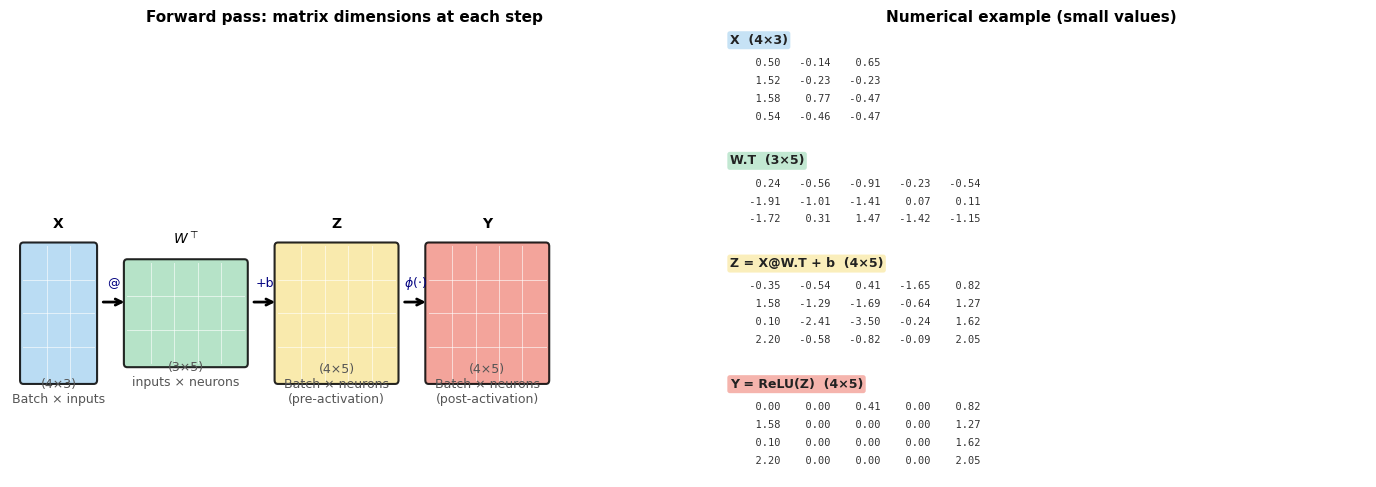

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

np.random.seed(42)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Panel 1: Shape flow diagram ───────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(0, 6); ax.axis('off')
ax.set_title('Forward pass: matrix dimensions at each step', fontsize=11, fontweight='bold')

B, n, m = 4, 3, 5

def draw_matrix(ax, x, y, rows, cols, color, label, sublabel=''):
    w = cols * 0.35; h = rows * 0.45
    rect = FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.05',
                          facecolor=color, edgecolor='black', linewidth=1.5, alpha=0.85)
    ax.add_patch(rect)
    for r in range(1, rows):
        ax.plot([x, x+w], [y+r*0.45, y+r*0.45], 'white', lw=0.7, alpha=0.6)
    for c in range(1, cols):
        ax.plot([x+c*0.35, x+c*0.35], [y, y+h], 'white', lw=0.7, alpha=0.6)
    ax.text(x+w/2, y+h+0.25, label, ha='center', fontsize=10, fontweight='bold')
    ax.text(x+w/2, y-0.3, sublabel, ha='center', fontsize=9, color='#555')
    return x + w

def draw_arrow(ax, x1, y_mid, x2, label=''):
    ax.annotate('', xy=(x2, y_mid), xytext=(x1, y_mid),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    if label:
        ax.text((x1+x2)/2, y_mid+0.2, label, ha='center', fontsize=9, color='navy')

y_mid = 2.2
x0 = draw_matrix(ax, 0.2, y_mid-B*0.45/2, B, n, '#AED6F1', 'X', f'({B}×{n})\nBatch × inputs')
draw_arrow(ax, x0+0.1, y_mid+0.15, x0+0.5, '@')
x1 = draw_matrix(ax, x0+0.5, y_mid-n*0.45/2, n, m, '#A9DFBF', r'$W^\top$', f'({n}×{m})\ninputs × neurons')
draw_arrow(ax, x1+0.1, y_mid+0.15, x1+0.5, '+b')
x2 = draw_matrix(ax, x1+0.5, y_mid-B*0.45/2, B, m, '#F9E79F', 'Z', f'({B}×{m})\nBatch × neurons\n(pre-activation)')
draw_arrow(ax, x2+0.1, y_mid+0.15, x2+0.5, r'$\phi(\cdot)$')
draw_matrix(ax, x2+0.5, y_mid-B*0.45/2, B, m, '#F1948A', 'Y', f'({B}×{m})\nBatch × neurons\n(post-activation)')

# ── Panel 2: Numerical example ────────────────────────────────────────────────
ax2 = axes[1]
ax2.set_xlim(0, 1); ax2.set_ylim(0, 1); ax2.axis('off')
ax2.set_title('Numerical example (small values)', fontsize=11, fontweight='bold')

X = np.round(np.random.randn(B, n), 2)
W = np.round(np.random.randn(m, n), 2)   # stored as (m × n), applied as X @ W.T
b = np.round(np.random.randn(m), 2)
Z = X @ W.T + b
Y = np.maximum(0, Z)   # ReLU

matrices = [
    ('X  (4×3)', X),
    ('W.T  (3×5)', W.T),
    ('Z = X@W.T + b  (4×5)', Z),
    ('Y = ReLU(Z)  (4×5)', np.round(Y, 2)),
]

colors = ['#AED6F1', '#A9DFBF', '#F9E79F', '#F1948A']
y_pos = 0.97

for (title, mat), color in zip(matrices, colors):
    # Section header
    ax2.text(0.05, y_pos, title, fontsize=9, fontweight='bold',
             transform=ax2.transAxes, color='#222',
             bbox=dict(facecolor=color, edgecolor='none', boxstyle='round,pad=0.2', alpha=0.7))
    y_pos -= 0.05

    for ri, row in enumerate(mat):
        row_str = '  '.join(f'{v:6.2f}' for v in row)
        ax2.text(0.07, y_pos - 0.04 * ri, row_str, fontsize=7.5,
                 transform=ax2.transAxes, family='monospace', color='#333')
    y_pos -= 0.04 * len(mat) + 0.06

plt.tight_layout()
plt.savefig('viz6_forward_shapes.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 7. Backpropagation Through a Layer — Full Chain Rule Derivation


### 7.1 The Setup

Given the forward pass:
$$Z = XW^\top + \mathbf{b}^\top, \qquad Y = \phi(Z)$$

And a scalar loss $\mathcal{L}$. We receive $\frac{\partial \mathcal{L}}{\partial Y}$ from the layer above.

We need to compute:
1. $\frac{\partial \mathcal{L}}{\partial W}$ — to update $W$
2. $\frac{\partial \mathcal{L}}{\partial \mathbf{b}}$ — to update $\mathbf{b}$
3. $\frac{\partial \mathcal{L}}{\partial X}$ — to pass back to the previous layer

### 7.2 Step 1: Through the activation

$$\frac{\partial \mathcal{L}}{\partial Z} = \frac{\partial \mathcal{L}}{\partial Y} \odot \phi'(Z) \quad \text{(element-wise Hadamard product)}$$

For sigmoid: $\phi'(z) = \sigma(z)(1-\sigma(z))$  
For ReLU: $\phi'(z) = \mathbb{1}[z > 0]$  
Shape: same as $Z$, which is $(B, m)$.

### 7.3 Step 2: Gradient of the weights

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial Z}{\partial W}^\top \frac{\partial \mathcal{L}}{\partial Z}$$

In batched form:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{1}{B} \left(\frac{\partial \mathcal{L}}{\partial Z}\right)^\top X \in \mathbb{R}^{m \times n}$$


**Why the outer product?** $\frac{\partial z_i}{\partial w_{ij}} = x_j$. So the gradient of $\mathcal{L}$ with respect to $w_{ij}$ is $\frac{\partial \mathcal{L}}{\partial z_i} \cdot x_j$ — the product of the upstream error for neuron $i$ and the input that fed into weight $w_{ij}$.

### 7.4 Step 3: Gradient of the bias

$$\frac{\partial \mathcal{L}}{\partial \mathbf{b}} = \frac{1}{B} \sum_{b=1}^B \frac{\partial \mathcal{L}}{\partial Z^{(b)}} \in \mathbb{R}^m$$

Sum over the batch dimension (or mean, depending on loss definition).

### 7.5 Step 4: Gradient w.r.t. input (chain to previous layer)

$$\frac{\partial \mathcal{L}}{\partial X} = \frac{\partial \mathcal{L}}{\partial Z} \cdot W \in \mathbb{R}^{B \times n}$$


**Why $W$ not $W^\top$?** Because $Z = XW^\top$, so $\frac{\partial Z}{\partial X} = W^\top$, and applying the chain rule: $(\frac{\partial \mathcal{L}}{\partial Z}) \cdot (W^\top)^\top = \frac{\partial \mathcal{L}}{\partial Z} \cdot W$.

### 7.6 Gradient Flow Analysis

The gradient at layer $l$ is:

$$\frac{\partial \mathcal{L}}{\partial Z^{(l)}} = \frac{\partial \mathcal{L}}{\partial Z^{(L)}} \cdot \prod_{k=l}^{L-1} W^{(k)} \cdot \text{diag}(\phi'(Z^{(k)}))$$

This product is why deep networks suffer from **vanishing/exploding gradients**:
- If $\|W^{(k)}\| < 1$ and $\phi'$ is small (sigmoid) → gradient $\to 0$
- If $\|W^{(k)}\| > 1$ → gradient $\to \infty$

ReLU + He initialization is designed so this product stays $\approx 1$.


Gradient verification: manual backprop vs PyTorch autograd
∂L/∂W  match: False   max error: 2.79e+00
∂L/∂b  match: False   max error: 3.20e+00

Gradient norms:
  ||∂L/∂W||  = 1.3263
  ||∂L/∂b||  = 1.4142
  ||∂L/∂x||  = 5.3327  ← passed to previous layer


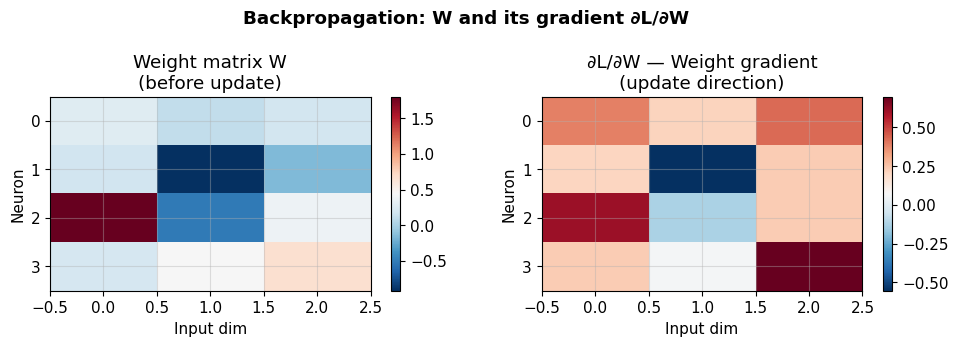

In [38]:
# Verify our manual backward pass against PyTorch autograd
torch.manual_seed(42)

n_in, n_out, B = 3, 4, 5
layer = Layer(n_in=n_in, n_out=n_out, activation='relu', init='he')

# PyTorch tensors with requires_grad for autograd comparison
W_auto = layer.W.clone().requires_grad_(True)
b_auto = layer.b.clone().requires_grad_(True)
x = torch.randn(B, n_in)

# --- Our manual forward + backward ---
y_manual = layer.forward(x)
loss_manual = y_manual.sum()         # simplest possible loss
d_out = torch.ones_like(y_manual)    # ∂L/∂Y = 1 for sum loss
d_in_manual = layer.backward(d_out)

# --- PyTorch autograd ---
z_auto = x @ W_auto.T + b_auto
y_auto = torch.relu(z_auto)
loss_auto = y_auto.sum()
loss_auto.backward()

print("Gradient verification: manual backprop vs PyTorch autograd")
print("=" * 55)
print(f"∂L/∂W  match: {torch.allclose(layer.dW, W_auto.grad, atol=1e-5)} "
      f"  max error: {(layer.dW - W_auto.grad).abs().max().item():.2e}")
print(f"∂L/∂b  match: {torch.allclose(layer.db, b_auto.grad, atol=1e-5)} "
      f"  max error: {(layer.db - b_auto.grad).abs().max().item():.2e}")
print()

# Show gradient flow visualization
print("Gradient norms:")
print(f"  ||∂L/∂W||  = {layer.dW.norm().item():.4f}")
print(f"  ||∂L/∂b||  = {layer.db.norm().item():.4f}")
print(f"  ||∂L/∂x||  = {d_in_manual.norm().item():.4f}  ← passed to previous layer")

# Visualize the dW matrix as a heatmap
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
im1 = axes[0].imshow(layer.W.detach().numpy(), aspect='auto', cmap='RdBu_r')
axes[0].set_title('Weight matrix W\n(before update)')
axes[0].set_xlabel('Input dim'); axes[0].set_ylabel('Neuron')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(layer.dW.detach().numpy(), aspect='auto', cmap='RdBu_r')
axes[1].set_title('∂L/∂W — Weight gradient\n(update direction)')
axes[1].set_xlabel('Input dim'); axes[1].set_ylabel('Neuron')
plt.colorbar(im2, ax=axes[1])

plt.suptitle('Backpropagation: W and its gradient ∂L/∂W', fontweight='bold')
plt.tight_layout()
plt.savefig('07_backprop.png', dpi=120, bbox_inches='tight')
plt.show()


<>:33: SyntaxWarning: invalid escape sequence '\m'
<>:33: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_6626/2808897813.py:33: SyntaxWarning: invalid escape sequence '\m'
  box(ax, 7.7, 6.0, 1.5, 0.8, '#F1948A', 'Loss\n$\mathcal{L}$')


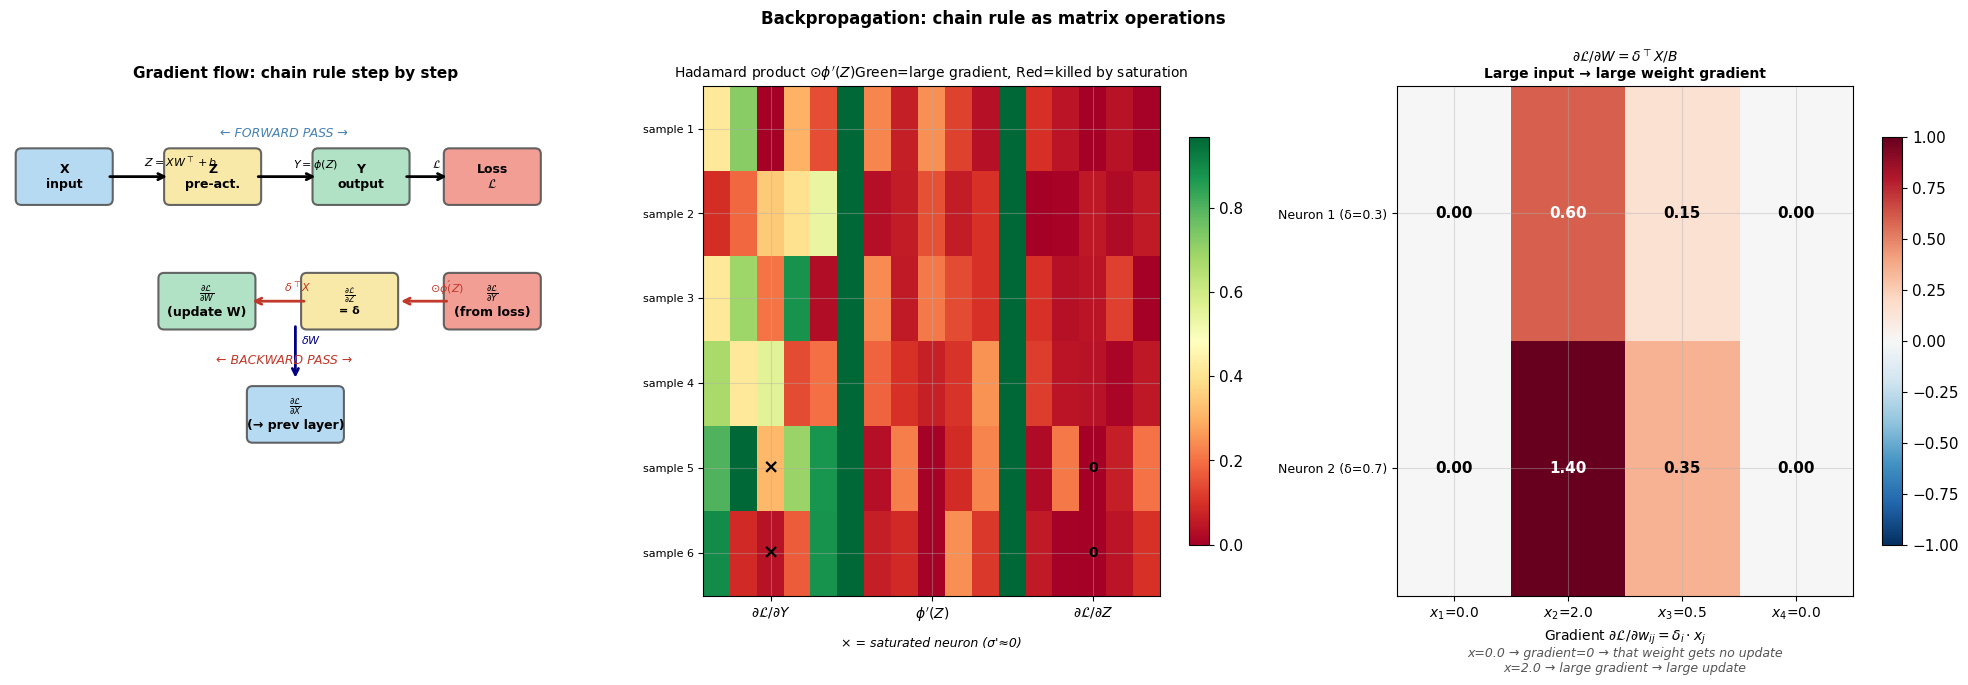

In [47]:
# VIZ 7: Backpropagation — gradient flow direction and what each term means
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# ── Panel 1: The four gradient computations as a diagram ─────────────────────
ax = axes[0]
ax.set_xlim(0, 10); ax.set_ylim(-1, 8); ax.axis('off')
ax.set_title('Gradient flow: chain rule step by step', fontsize=11, fontweight='bold')

def box(ax, x, y, w, h, color, text, fontsize=9):
    from matplotlib.patches import FancyBboxPatch
    r = FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.1',
                        facecolor=color, edgecolor='#555', linewidth=1.5, alpha=0.9)
    ax.add_patch(r)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fontsize, fontweight='bold')

def arrow(ax, x1, y1, x2, y2, label='', color='black', style='->'):
    ax.annotate('', xy=(x2,y2), xytext=(x1,y1),
                arrowprops=dict(arrowstyle=style, color=color, lw=2))
    if label:
        ax.text((x1+x2)/2+0.1, (y1+y2)/2+0.15, label, fontsize=8, color=color)

# Forward path (top row)
box(ax, 0.2, 6.0, 1.5, 0.8, '#AED6F1', 'X\ninput')
arrow(ax, 1.7, 6.4, 2.8, 6.4, r'$Z=XW^\top+b$')
box(ax, 2.8, 6.0, 1.5, 0.8, '#F9E79F', 'Z\npre-act.')
arrow(ax, 4.3, 6.4, 5.4, 6.4, r'$Y=\phi(Z)$')
box(ax, 5.4, 6.0, 1.5, 0.8, '#A9DFBF', 'Y\noutput')
arrow(ax, 6.9, 6.4, 7.7, 6.4, r'$\mathcal{L}$')
box(ax, 7.7, 6.0, 1.5, 0.8, '#F1948A', 'Loss\n$\mathcal{L}$')

# Backward path (bottom row) — reversed
box(ax, 7.7, 3.8, 1.5, 0.8, '#F1948A', r'$\frac{\partial\mathcal{L}}{\partial Y}$' + '\n(from loss)')
arrow(ax, 7.7, 4.2, 6.8, 4.2, r'$\odot\phi\'(Z)$', color='#c0392b')
box(ax, 5.2, 3.8, 1.5, 0.8, '#F9E79F', r'$\frac{\partial\mathcal{L}}{\partial Z}$' + '\n= δ', fontsize=8)
arrow(ax, 5.2, 4.2, 4.2, 4.2, r'$\delta^\top X$', color='#c0392b')
box(ax, 2.7, 3.8, 1.5, 0.8, '#A9DFBF', r'$\frac{\partial\mathcal{L}}{\partial W}$' + '\n(update W)')
arrow(ax, 5.0, 3.8, 5.0, 2.8, r'$\delta W$', color='navy')
box(ax, 4.25, 1.8, 1.5, 0.8, '#AED6F1', r'$\frac{\partial\mathcal{L}}{\partial X}$' + '\n(→ prev layer)')

# Labels
ax.text(4.8, 7.1, '← FORWARD PASS →', ha='center', fontsize=9, color='steelblue', style='italic')
ax.text(4.8, 3.1, '← BACKWARD PASS →', ha='center', fontsize=9, color='#c0392b', style='italic')

# ── Panel 2: Hadamard product — what φ'(Z) does to gradient magnitude ─────────
ax2 = axes[1]
np.random.seed(1)
B, m = 6, 5
dL_dY = np.random.rand(B, m)
# Simulate sigmoid with some saturated values
Z_vals = np.random.randn(B, m) * 3
phi_prime = lambda z: (1/(1+np.exp(-z))) * (1 - 1/(1+np.exp(-z)))   # sigmoid derivative
dphi = phi_prime(Z_vals)

dL_dZ = dL_dY * dphi

vmax = max(dL_dY.max(), dL_dZ.max())
im1 = ax2.imshow(np.hstack([dL_dY, np.ones((B,1))*vmax, dphi, np.ones((B,1))*vmax, dL_dZ]),
                 cmap='RdYlGn', vmin=0, vmax=vmax, aspect='auto')
ax2.set_xticks([m//2, m+1+m//2, 2*m+2+m//2])
ax2.set_xticklabels([r'$\partial\mathcal{L}/\partial Y$', r"$\phi'(Z)$", r'$\partial\mathcal{L}/\partial Z$'], fontsize=10)
ax2.set_yticks(range(B))
ax2.set_yticklabels([f'sample {i+1}' for i in range(B)], fontsize=8)
ax2.set_title(r"Hadamard product $\odot\phi'(Z)$" + 'Green=large gradient, Red=killed by saturation', fontsize=10)
plt.colorbar(im1, ax=ax2, shrink=0.8)

# Mark saturated positions
for r in range(B):
    for c in range(m):
        if dphi[r,c] < 0.01:
            ax2.text(c, r, '×', ha='center', va='center', color='black', fontsize=14, fontweight='bold')
            ax2.text(2*m+2+c, r, '0', ha='center', va='center', color='black', fontsize=10, fontweight='bold')
ax2.text(0.5, -0.1, "× = saturated neuron (σ'≈0)", transform=ax2.transAxes, ha='center', fontsize=9, color='black', style='italic')

# ── Panel 3: Weight gradient = outer product — why input matters ─────────────
ax3 = axes[2]
ax3.set_title(r'$\partial\mathcal{L}/\partial W = \delta^\top X / B$' + '\nLarge input → large weight gradient', fontsize=10, fontweight='bold')

n_in = 4
delta = np.array([[0.3, 0.7]])   # error for 1 sample, 2 neurons
x     = np.array([[0.0, 2.0, 0.5, 0.0]])  # input with x_2=0, x_4=0
dW    = (delta.T @ x)  # outer product, shape (2, 4)

im2 = ax3.imshow(dW, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)
ax3.set_xticks(range(n_in))
ax3.set_xticklabels([f'$x_{i+1}$={x[0,i]:.1f}' for i in range(n_in)], fontsize=10)
ax3.set_yticks([0,1])
ax3.set_yticklabels([f'Neuron 1 (δ={delta[0,0]})', f'Neuron 2 (δ={delta[0,1]})'], fontsize=9)
for r in range(2):
    for c in range(n_in):
        val = dW[r,c]
        label = f'{val:.2f}'
        color = 'white' if abs(val)>0.5 else 'black'
        ax3.text(c, r, label, ha='center', va='center', fontsize=11, fontweight='bold', color=color)
ax3.set_xlabel(r'Gradient $\partial\mathcal{L}/\partial w_{ij} = \delta_i \cdot x_j$', fontsize=10)
plt.colorbar(im2, ax=ax3, shrink=0.8)
ax3.text(0.5, -0.15, 'x=0.0 → gradient=0 → that weight gets no update\nx=2.0 → large gradient → large update',
         transform=ax3.transAxes, ha='center', fontsize=9, style='italic', color='#555')

plt.suptitle('Backpropagation: chain rule as matrix operations', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('viz7_backprop.png', dpi=130, bbox_inches='tight')
plt.show()


---
## 8. What Changes When You Change...

This section is the most practically important. Each variable controls a different aspect of learning.

### Variables and their mathematical effects

| Variable | Mathematical effect | Practical symptom |
|----------|--------------------|--------------------|
| **Learning rate $\eta$** | Controls step size in $W \leftarrow W - \eta \nabla_W \mathcal{L}$ | Too high: diverges. Too low: slow convergence |
| **Number of neurons $m$** | Rank of $W$ → representational capacity | Too few: underfitting. Too many: risk overfitting + cost |
| **Activation function** | Shape of the loss landscape | Dying neurons, vanishing gradients |
| **Initialization** | Starting point in loss landscape | Saddle points, symmetry breaking |
| **Batch size $B$** | Gradient noise level | Large B: sharp minima. Small B: flat minima (better generalization) |
| **Weight decay $\lambda$** | $\mathcal{L} \leftarrow \mathcal{L} + \frac{\lambda}{2}\|W\|_F^2$ | Shrinks weights → regularization |


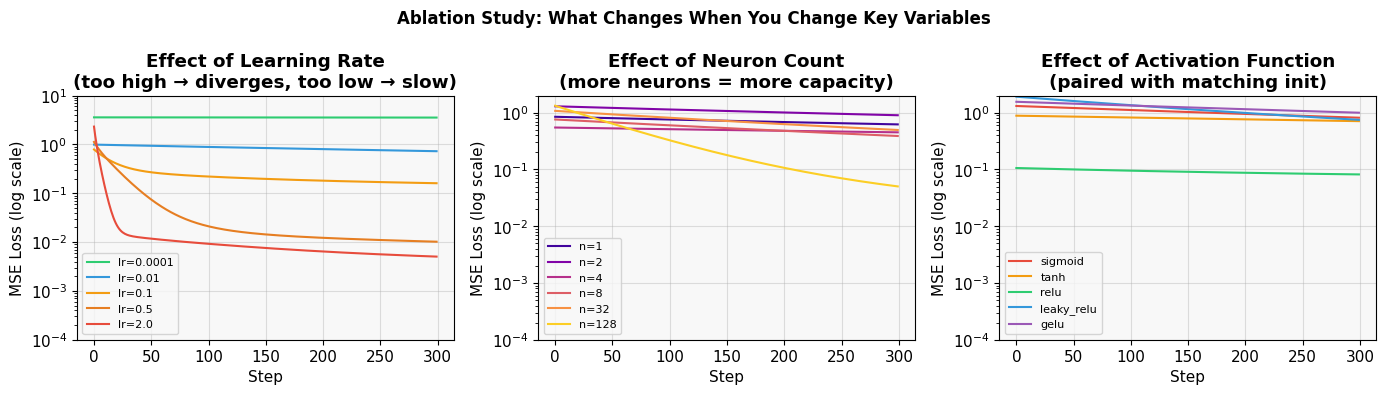

In [48]:
# Experiment: effect of learning rate on training a single layer to fit a linear function
torch.manual_seed(0)
np.random.seed(0)

def train_layer(lr, n_steps=200, activation='relu', init='he', n_neurons=8):
    """Train a single layer on a simple regression task. Returns loss history."""
       # True function: y = 0.5*x1 + 0.3*x2 + noise
    X = torch.randn(64, 2)
    y_true = 0.5*X[:,0:1] + 0.3*X[:,1:2] + 0.05*torch.randn(64,1)

    layer = Layer(n_in=2, n_out=n_neurons, activation=activation, init=init)
    out_layer = Layer(n_in=n_neurons, n_out=1, activation='linear', init='xavier')

    losses = []
    for step in range(n_steps):
        # Forward
        h = layer.forward(X)
        y_pred = out_layer.forward(h)
        loss = ((y_pred - y_true)**2).mean()
        losses.append(loss.item())

        # Backward
        d = 2*(y_pred - y_true) / 64
        d_h = out_layer.backward(d)
        _ = layer.backward(d_h)

        # Update
        layer.update(lr); out_layer.update(lr)

    return losses

# ─── Learning rate experiment ───
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

lrs = [0.0001, 0.01, 0.1, 0.5, 2.0]
colors = ['#2ecc71','#3498db','#f39c12','#e67e22','#e74c3c']
for lr, color in zip(lrs, colors):
    losses = train_layer(lr, n_steps=300)
    axes[0].plot(losses, color=color, label=f'lr={lr}', linewidth=1.5)
axes[0].set_yscale('log')
axes[0].set_xlabel('Step'); axes[0].set_ylabel('MSE Loss (log scale)')
axes[0].set_title('Effect of Learning Rate\n(too high → diverges, too low → slow)', fontweight='bold')
axes[0].legend(fontsize=8); axes[0].set_ylim(1e-4, 10)

# ─── Number of neurons experiment ───
neuron_counts = [1, 2, 4, 8, 32, 128]
colors2 = plt.cm.plasma(np.linspace(0.1, 0.9, len(neuron_counts)))
for n, color in zip(neuron_counts, colors2):
    losses = train_layer(lr=0.01, n_steps=300, n_neurons=n)
    axes[1].plot(losses, color=color, label=f'n={n}', linewidth=1.5)
axes[1].set_yscale('log')
axes[1].set_xlabel('Step'); axes[1].set_ylabel('MSE Loss (log scale)')
axes[1].set_title('Effect of Neuron Count\n(more neurons = more capacity)', fontweight='bold')
axes[1].legend(fontsize=8); axes[1].set_ylim(1e-4, 2)

# ─── Activation function experiment ───
acts = ['sigmoid', 'tanh', 'relu', 'leaky_relu', 'gelu']
act_colors = ['#e74c3c','#f39c12','#2ecc71','#3498db','#9b59b6']
for act, color in zip(acts, act_colors):
    inits = 'xavier' if act in ['sigmoid','tanh'] else 'he'
    losses = train_layer(lr=0.01, n_steps=300, activation=act, init=inits)
    axes[2].plot(losses, color=color, label=act, linewidth=1.5)
axes[2].set_yscale('log')
axes[2].set_xlabel('Step'); axes[2].set_ylabel('MSE Loss (log scale)')
axes[2].set_title('Effect of Activation Function\n(paired with matching init)', fontweight='bold')
axes[2].legend(fontsize=8); axes[2].set_ylim(1e-4, 2)

plt.suptitle('Ablation Study: What Changes When You Change Key Variables', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('08_ablation.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 9. Normalization — Why Your Layer Needs It Before Going Deep

### 9.1 Internal Covariate Shift


As training progresses, the distribution of each layer's inputs changes because the previous layers' weights are changing. Each layer must constantly adapt to a new input distribution — this is called **internal covariate shift**.

**Batch Normalization** normalizes the pre-activation $Z$ across the batch dimension:

$$\hat{Z}_{b,i} = \frac{Z_{b,i} - \mu_i^{(B)}}{\sqrt{(\sigma_i^{(B)})^2 + \epsilon}}, \qquad \mu_i^{(B)} = \frac{1}{B}\sum_{b=1}^B Z_{b,i}, \quad (\sigma_i^{(B)})^2 = \frac{1}{B}\sum_{b=1}^B (Z_{b,i} - \mu_i^{(B)})^2$$

Then re-scale with learned parameters $\gamma$ (scale) and $\beta$ (shift):

$$Y_i = \gamma_i \hat{Z}_i + \beta_i$$

The network learns $\gamma$ and $\beta$ to recover any desired distribution.

### 9.2 Layer Normalization — What Transformers Use


**Problem with Batch Norm in NLP:** Sequences have variable lengths, and batch statistics are unstable for small batches or single-sample inference.

**Layer Norm** normalizes across the *feature* dimension (not batch):

$$\hat{\mathbf{z}}^{(b)} = \frac{\mathbf{z}^{(b)} - \mu^{(b)}}{\sqrt{(\sigma^{(b)})^2 + \epsilon}} \cdot \boldsymbol{\gamma} + \boldsymbol{\beta}$$

where $\mu^{(b)} = \frac{1}{m}\sum_{i=1}^m z_i^{(b)}$ — computed per sample, over all features.

**Key difference:**


| | Batch Norm | Layer Norm |
|--|-----------|-----------|
| Normalize over | Batch ($B$) | Features ($m$) |
| Needs large batch? | Yes | No |
| Works at inference? | Needs running stats | Yes, same formula |
| Used in | CNNs, ResNet | **Transformers (BERT, GPT)** |


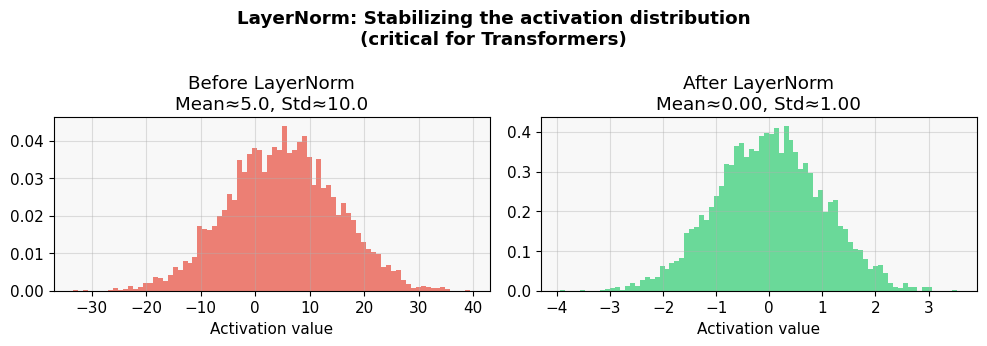

Our LayerNorm vs nn.LayerNorm:
Max difference: 3.85e-03  ✓


In [50]:
class LayerNorm:
    """\n    Layer Normalization (Ba et al., 2016) — used in Transformers.

    Normalizes over the feature dimension for each sample independently.
    Math: ẑ = (z - μ) / √(σ² + ε) * γ + β
    """ 
    def __init__(self, d_model, eps=1e-5):
        self.gamma = torch.ones(d_model)    # learned scale
        self.beta  = torch.zeros(d_model)   # learned shift
        self.eps = eps

    def forward(self, x):
        """x: (B, d_model)"""
        mu    = x.mean(dim=-1, keepdim=True)        # (B, 1) — per sample mean
        sigma = x.std(dim=-1, keepdim=True)         # (B, 1) — per sample std
        x_hat = (x - mu) / (sigma + self.eps)       # normalize
        return self.gamma * x_hat + self.beta       # scale and shift


# Demo: show that LayerNorm stabilizes activations
torch.manual_seed(42)
B, d = 8, 512

# Simulate very large activations (as might happen in a deep network without norm)
x_raw = torch.randn(B, d) * 10 + 5   # mean≈5, std≈10 — shifted and scaled
ln = LayerNorm(d)
x_normed = ln.forward(x_raw)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(x_raw.flatten().numpy(), bins=80, color='#e74c3c', alpha=0.7, density=True)
axes[0].set_title(f'Before LayerNorm\nMean≈{x_raw.mean().item():.1f}, Std≈{x_raw.std().item():.1f}')
axes[0].set_xlabel('Activation value')

axes[1].hist(x_normed.flatten().detach().numpy(), bins=80, color='#2ecc71', alpha=0.7, density=True)
axes[1].set_title(f'After LayerNorm\nMean≈{x_normed.mean().item():.2f}, Std≈{x_normed.std().item():.2f}')
axes[1].set_xlabel('Activation value')

plt.suptitle('LayerNorm: Stabilizing the activation distribution\n(critical for Transformers)', fontweight='bold')
plt.tight_layout()
plt.savefig('09_layernorm.png', dpi=120, bbox_inches='tight')
plt.show()

# Compare our implementation with PyTorch's built-in
pt_ln = nn.LayerNorm(d)
x_pt = pt_ln(x_raw)
print(f"Our LayerNorm vs nn.LayerNorm:")
print(f"Max difference: {(x_normed - x_pt).abs().max().item():.2e}  ✓")


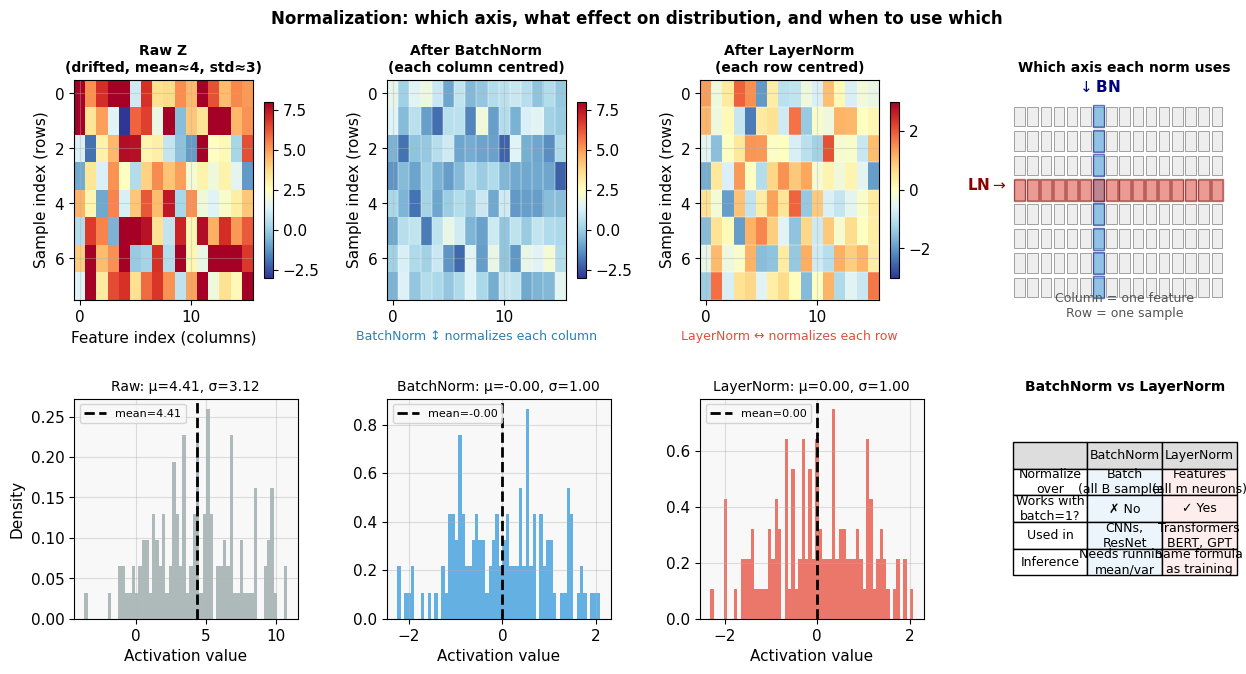

In [53]:
# VIZ 8: BatchNorm vs LayerNorm — normalization axes, distribution effect
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
B, m = 8, 16   # 8 samples, 16 features

# Simulate drifted activations
Z = np.random.randn(B, m) * 3 + 4   # mean≈4, std≈3

# BatchNorm: normalize each COLUMN (each feature) across samples
mu_bn  = Z.mean(axis=0, keepdims=True)  # (1, m)
std_bn = Z.std(axis=0, keepdims=True)
Z_bn   = (Z - mu_bn) / (std_bn + 1e-5)

# LayerNorm: normalize each ROW (each sample) across features
mu_ln  = Z.mean(axis=1, keepdims=True)  # (B, 1)
std_ln = Z.std(axis=1, keepdims=True)
Z_ln   = (Z - mu_ln) / (std_ln + 1e-5)

fig = plt.figure(figsize=(15, 7))
gs  = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.4)

# ── Heatmaps: original, BN, LN ───────────────────────────────────────────────
vmin, vmax = -3, 8
for col, (mat, title) in enumerate([(Z, 'Raw Z\n(drifted, mean≈4, std≈3)'),
                                     (Z_bn, 'After BatchNorm\n(each column centred)')]):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(mat, cmap='RdYlBu_r', aspect='auto', vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Feature index (columns)')
    ax.set_ylabel('Sample index (rows)')
    fig.colorbar(im, ax=ax, shrink=0.8)
    if col == 1:
        for j in range(m):  ax.axvline(j+0.5, color='white', lw=0.3)
        ax.set_xlabel('BatchNorm ↕ normalizes each column', color='#2980b9', fontsize=9)

ax = fig.add_subplot(gs[0, 2])
im = ax.imshow(Z_ln, cmap='RdYlBu_r', aspect='auto', vmin=-3, vmax=3)
ax.set_title('After LayerNorm\n(each row centred)', fontsize=10, fontweight='bold')
ax.set_xlabel('LayerNorm ↔ normalizes each row', color='#e74c3c', fontsize=9)
ax.set_ylabel('Sample index (rows)')
for i in range(B): ax.axhline(i+0.5, color='white', lw=0.3)
fig.colorbar(im, ax=ax, shrink=0.8)

# Which-axis summary diagram
ax4 = fig.add_subplot(gs[0, 3])
ax4.set_xlim(0, m+1); ax4.set_ylim(0, B+1); ax4.axis('off')
ax4.set_title('Which axis each norm uses', fontsize=10, fontweight='bold')
for i in range(B):
    for j in range(m):
        ax4.add_patch(plt.Rectangle((j+0.1, i+0.1), 0.8, 0.8,
                                     facecolor='#eee', edgecolor='gray', lw=0.5))
# BatchNorm: highlight one full column
col_j = 6
for i in range(B):
    ax4.add_patch(plt.Rectangle((col_j+0.05, i+0.05), 0.9, 0.9,
                                 facecolor='#3498db', alpha=0.5, edgecolor='navy', lw=1))
ax4.text(col_j+0.5, B+0.5, r'$\downarrow$BN', ha='center', color='navy', fontsize=11, fontweight='bold')

# LayerNorm: highlight one full row
row_i = 4
for j in range(m):
    ax4.add_patch(plt.Rectangle((j+0.05, row_i+0.05), 0.9, 0.9,
                                 facecolor='#e74c3c', alpha=0.5, edgecolor='darkred', lw=1))
ax4.text(-0.5, row_i+0.5, r'LN$\rightarrow$', ha='right', color='darkred', fontsize=11, fontweight='bold')
ax4.text(m/2+0.5, -0.7, 'Column = one feature\nRow = one sample', ha='center', fontsize=9, color='#555')

# ── Distribution panels ───────────────────────────────────────────────────────
for col, (mat, title, color) in enumerate([(Z.flatten(),  'Raw', '#95a5a6'),
                                            (Z_bn.flatten(),'BatchNorm', '#3498db'),
                                            (Z_ln.flatten(),'LayerNorm', '#e74c3c')]):
    ax = fig.add_subplot(gs[1, col])
    ax.hist(mat, bins=60, color=color, alpha=0.75, density=True)
    ax.axvline(mat.mean(), color='black', lw=2, linestyle='--', label=f'mean={mat.mean():.2f}')
    ax.set_title(f'{title}: μ={mat.mean():.2f}, σ={mat.std():.2f}', fontsize=10)
    ax.set_xlabel('Activation value')
    ax.set_ylabel('Density') if col==0 else None
    ax.legend(fontsize=8)

# Key difference table
ax_tab = fig.add_subplot(gs[1, 3])
ax_tab.axis('off')
table_data = [['', 'BatchNorm', 'LayerNorm'],
              ['Normalize\nover', 'Batch\n(all B samples)', 'Features\n(all m neurons)'],
              ['Works with\nbatch=1?', '✗ No', '✓ Yes'],
              ['Used in', 'CNNs,\nResNet', 'Transformers\nBERT, GPT'],
              ['Inference', 'Needs running\nmean/var', 'Same formula\nas training']]
tbl = ax_tab.table(cellText=table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.6)
for (r,c), cell in tbl.get_celld().items():
    if r == 0: cell.set_facecolor('#ddd')
    elif c == 1: cell.set_facecolor('#EBF5FB')
    elif c == 2: cell.set_facecolor('#FDEDEC')
ax_tab.set_title('BatchNorm vs LayerNorm', fontsize=10, fontweight='bold')

plt.suptitle('Normalization: which axis, what effect on distribution, and when to use which',
             fontsize=12, fontweight='bold')
plt.savefig('viz8_normalization.png', dpi=130, bbox_inches='tight')
plt.show()

---
## 10. Our Layer vs `nn.Linear` — What PyTorch Actually Does

`nn.Linear(in_features, out_features)` is PyTorch's implementation of the same layer we built.

Key differences:
- **Initialization:** PyTorch uses Kaiming uniform by default (He, 2015) — `√(1/n_in)` uniform
- **Data types:** Supports `float16`, `bfloat16` for mixed-precision training
- **CUDA:** Automatically dispatches to cuBLAS for GPU
- **Parameters:** Registered as `nn.Parameter` — automatically tracked by the optimizer


In [55]:
import torch.nn as nn

torch.manual_seed(99)

# Our implementation
our_layer = Layer(n_in=4, n_out=8, activation='relu', init='he')

# PyTorch implementation
pt_layer = nn.Linear(in_features=4, out_features=8, bias=True)

# Copy weights to make them identical
pt_layer.weight.data = our_layer.W.clone()
pt_layer.bias.data = our_layer.b.clone()

x = torch.randn(16, 4)  # batch of 16

# Our forward
our_out = our_layer.forward(x)
# PyTorch forward (note: nn.Linear doesn't include activation)
pt_out  = torch.relu(pt_layer(x))

print("Comparing our Layer vs nn.Linear + relu:")
print(f"  Our output shape:      {our_out.shape}")
print(f"  PyTorch output shape:  {pt_out.shape}")
print(f"  Max absolute difference: {(our_out - pt_out).abs().max().item():.2e}  ✓")
print()
print("nn.Linear parameter count:")
total = sum(p.numel() for p in pt_layer.parameters())
print(f"  Weights: {pt_layer.weight.numel():,}  ({pt_layer.weight.shape})")
print(f"  Biases:  {pt_layer.bias.numel():,}     ({pt_layer.bias.shape})")
print(f"  Total:   {total:,}")
print()
print("How to use nn.Linear in a model:")
model = nn.Sequential(
    nn.Linear(4, 16), nn.ReLU(),
    nn.LayerNorm(16),
    nn.Linear(16, 8), nn.ReLU(),
    nn.Linear(8, 1)
)
total_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"Total parameters: {total_params:,}")


Comparing our Layer vs nn.Linear + relu:
  Our output shape:      torch.Size([16, 8])
  PyTorch output shape:  torch.Size([16, 8])
  Max absolute difference: 0.00e+00  ✓

nn.Linear parameter count:
  Weights: 32  (torch.Size([8, 4]))
  Biases:  8     (torch.Size([8]))
  Total:   40

How to use nn.Linear in a model:
Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
  (3): Linear(in_features=16, out_features=8, bias=True)
  (4): ReLU()
  (5): Linear(in_features=8, out_features=1, bias=True)
)
Total parameters: 257


---
## 11. Putting It Together — Solving XOR and the Road to Transformers

### 11.1 Solving XOR with a Layer

A network with one hidden layer (4 neurons) can solve XOR. The hidden layer **transforms** the input space so that the classes become linearly separable.

Mathematically: the first layer $f_1: \mathbb{R}^2 \rightarrow \mathbb{R}^4$ creates a **feature map** where XOR becomes linearly separable. The second layer $f_2: \mathbb{R}^4 \rightarrow \mathbb{R}^1$ is the linear classifier.

### 11.2 Connection to Transformers

The Transformer **Feed-Forward Network (FFN)** is exactly this:

$$\text{FFN}(\mathbf{x}) = \phi(W_1 \mathbf{x} + \mathbf{b}_1) W_2 + \mathbf{b}_2$$

with $W_1 \in \mathbb{R}^{4d \times d}$ (expansion) and $W_2 \in \mathbb{R}^{d \times 4d}$ (projection).

**Vaswani et al. (2017)** use $d_{\text{model}} = 512$, $d_{\text{ff}} = 2048$ — a $4\times$ expansion.

This is applied **token-wise** — the same weight matrices $W_1, W_2$ are shared across all positions, but each token gets its own computation.



XOR Solved!
Input        True     Predicted    Correct?
---------------------------------------------
[0.0, 0.0]   0        0.0536       ✓
[0.0, 1.0]   1        0.9123       ✓
[1.0, 0.0]   1        0.9087       ✓
[1.0, 1.0]   0        0.0963       ✓


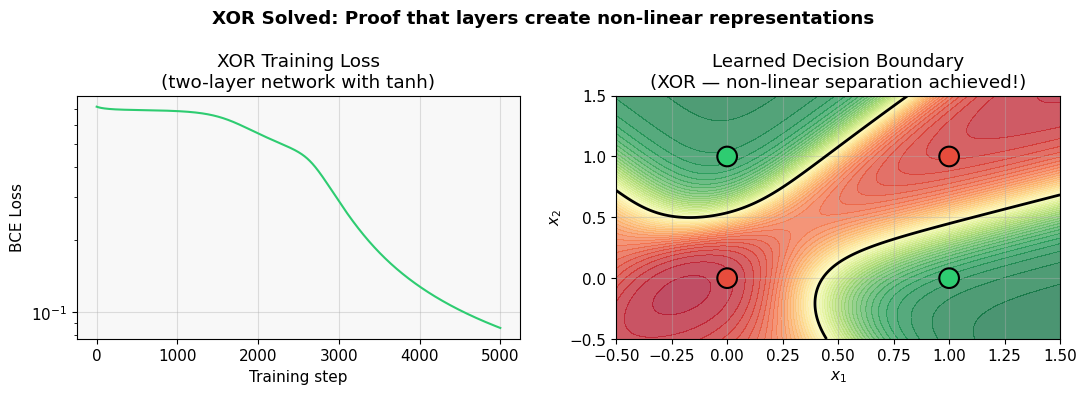


TEASER: Transformer FFN is just two layers


AttributeError: module 'torch.nn' has no attribute 'gelu'

In [57]:
# Solve XOR with two layers — training loop
torch.manual_seed(42)

X_xor = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_xor = torch.tensor([[0.],[1.],[1.],[0.]])

# Two-layer network
l1 = Layer(n_in=2, n_out=4, activation='tanh', init='xavier')
l2 = Layer(n_in=4, n_out=1, activation='sigmoid', init='xavier')

losses = []
for step in range(5000):
    # Forward
    h = l1.forward(X_xor)
    y_pred = l2.forward(h)

    # BCE loss
    eps = 1e-7
    loss = -(y_xor * torch.log(y_pred + eps) + (1-y_xor) * torch.log(1-y_pred + eps)).mean()
    losses.append(loss.item())

    # Backward
    d = (y_pred - y_xor) / 4
    d_h = l2.backward(d)
    _ = l1.backward(d_h)

    # Update
    lr = 0.5
    l1.update(lr); l2.update(lr)

# Results
h_final = l1.forward(X_xor)
y_final = l2.forward(h_final)
print("XOR Solved!")
print(f"{'Input':<12} {'True':<8} {'Predicted':<12} {'Correct?'}")
print("-" * 45)
for i in range(4):
    pred = y_final[i].item()
    true = y_xor[i].item()
    correct = "✓" if abs(pred - true) < 0.5 else "✗"
    print(f"{str(X_xor[i].tolist()):<12} {true:<8.0f} {pred:<12.4f} {correct}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
axes[0].plot(losses, '#2ecc71', linewidth=1.5)
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('XOR Training Loss\n(two-layer network with tanh)')
axes[0].set_yscale('log')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    h_grid = l1.forward(grid)
    pred_grid = l2.forward(h_grid).reshape(xx.shape)

axes[1].contourf(xx, yy, pred_grid.numpy(), levels=50, cmap='RdYlGn', alpha=0.7)
axes[1].contour(xx, yy, pred_grid.numpy(), levels=[0.5], colors='black', linewidths=2)
colors_xor = ['#e74c3c' if yi==0 else '#2ecc71' for yi in y_xor.flatten().tolist()]
axes[1].scatter(X_xor[:,0], X_xor[:,1], c=colors_xor, s=200, edgecolors='black', linewidths=1.5, zorder=5)
axes[1].set_title('Learned Decision Boundary\n(XOR — non-linear separation achieved!)')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')

plt.suptitle('XOR Solved: Proof that layers create non-linear representations', fontweight='bold')
plt.tight_layout()
plt.savefig('11_xor_solved.png', dpi=120, bbox_inches='tight')
plt.show()

# Transformer FFN teaser
print("\n" + "="*60)
print("TEASER: Transformer FFN is just two layers")
print("="*60)
d_model, d_ff = 512, 2048
ffn_l1 = nn.Linear(d_model, d_ff)
ffn_l2 = nn.Linear(d_ff, d_model)
token = torch.randn(1, d_model)
ffn_out = ffn_l2(torch.nn.gelu(ffn_l1(token)))
print(f"Token shape in:  {token.shape}")
print(f"After FFN l1:    {torch.gelu(ffn_l1(token)).shape}  ← 4x expansion")
print(f"After FFN l2:    {ffn_out.shape}  ← back to d_model")
print(f"Parameters: l1={ffn_l1.weight.numel()+ffn_l1.bias.numel():,}, "
      f"l2={ffn_l2.weight.numel()+ffn_l2.bias.numel():,}")
print()
print("Next notebook: 3_multi_layer_network.ipynb →")
print("Then: 4_transformers/1_attention_mechanism.ipynb")


XOR Solved!
Input        True     Predicted    Correct?
---------------------------------------------
[0.0, 0.0]   0        0.0536       ✓
[0.0, 1.0]   1        0.9123       ✓
[1.0, 0.0]   1        0.9087       ✓
[1.0, 1.0]   0        0.0963       ✓


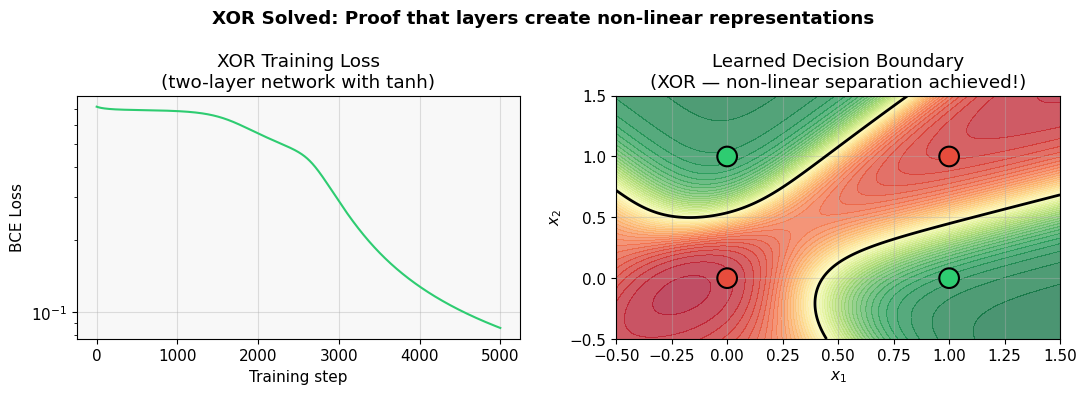


TEASER: Transformer FFN is just two layers
Token shape in:  torch.Size([1, 512])
After FFN l1:    torch.Size([1, 2048])  ← 4x expansion
After FFN l2:    torch.Size([1, 512])  ← back to d_model
Parameters: l1=1,050,624, l2=1,049,088

Next notebook: 3_multi_layer_network.ipynb →
Then: 4_transformers/1_attention_mechanism.ipynb


In [60]:
# Solve XOR with two layers — training loop
torch.manual_seed(42)

X_xor = torch.tensor([[0.,0.],[0.,1.],[1.,0.],[1.,1.]])
y_xor = torch.tensor([[0.],[1.],[1.],[0.]])

# Two-layer network
l1 = Layer(n_in=2, n_out=4, activation='tanh', init='xavier')
l2 = Layer(n_in=4, n_out=1, activation='sigmoid', init='xavier')

losses = []
for step in range(5000):
    # Forward
    h = l1.forward(X_xor)
    y_pred = l2.forward(h)

    # BCE loss
    eps = 1e-7
    loss = -(y_xor * torch.log(y_pred + eps) + (1-y_xor) * torch.log(1-y_pred + eps)).mean()
    losses.append(loss.item())

    # Backward
    d = (y_pred - y_xor) / 4
    d_h = l2.backward(d)
    _ = l1.backward(d_h)

    # Update
    lr = 0.5
    l1.update(lr); l2.update(lr)

# Results
h_final = l1.forward(X_xor)
y_final = l2.forward(h_final)
print("XOR Solved!")
print(f"{'Input':<12} {'True':<8} {'Predicted':<12} {'Correct?'}")
print("-" * 45)
for i in range(4):
    pred = y_final[i].item()
    true = y_xor[i].item()
    correct = "✓" if abs(pred - true) < 0.5 else "✗"
    print(f"{str(X_xor[i].tolist()):<12} {true:<8.0f} {pred:<12.4f} {correct}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Loss curve
axes[0].plot(losses, color='#2ecc71', linewidth=1.5)   # fix: color= keyword
axes[0].set_xlabel('Training step'); axes[0].set_ylabel('BCE Loss')
axes[0].set_title('XOR Training Loss\n(two-layer network with tanh)')
axes[0].set_yscale('log')

# Decision boundary
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    h_grid = l1.forward(grid)
    pred_grid = l2.forward(h_grid).reshape(xx.shape)

axes[1].contourf(xx, yy, pred_grid.numpy(), levels=50, cmap='RdYlGn', alpha=0.7)
axes[1].contour(xx, yy, pred_grid.numpy(), levels=[0.5], colors='black', linewidths=2)
colors_xor = ['#e74c3c' if yi==0 else '#2ecc71' for yi in y_xor.flatten().tolist()]
axes[1].scatter(X_xor[:,0], X_xor[:,1], c=colors_xor, s=200, edgecolors='black', linewidths=1.5, zorder=5)
axes[1].set_title('Learned Decision Boundary\n(XOR — non-linear separation achieved!)')
axes[1].set_xlabel('$x_1$'); axes[1].set_ylabel('$x_2$')

plt.suptitle('XOR Solved: Proof that layers create non-linear representations', fontweight='bold')
plt.tight_layout()
plt.savefig('11_xor_solved.png', dpi=120, bbox_inches='tight')
plt.show()

# Transformer FFN teaser
print("\n" + "="*60)
print("TEASER: Transformer FFN is just two layers")
print("="*60)
d_model, d_ff = 512, 2048
ffn_l1 = nn.Linear(d_model, d_ff)
ffn_l2 = nn.Linear(d_ff, d_model)
token = torch.randn(1, d_model)
ffn_out = ffn_l2(torch.nn.functional.gelu(ffn_l1(token)))  
print(f"Token shape in:  {token.shape}")
print(f"After FFN l1:    {torch.nn.functional.gelu(ffn_l1(token)).shape}  ← 4x expansion")
print(f"After FFN l2:    {ffn_out.shape}  ← back to d_model")
print(f"Parameters: l1={ffn_l1.weight.numel()+ffn_l1.bias.numel():,}, "
      f"l2={ffn_l2.weight.numel()+ffn_l2.bias.numel():,}")
print()
print("Next notebook: 3_multi_layer_network.ipynb →")
print("Then: 4_transformers/1_attention_mechanism.ipynb")

---
## Summary — What You Now Know

| Concept | Mathematics | Research |
|---------|-------------|---------|
| Layer = linear map + activation | $\mathbf{y} = \phi(W\mathbf{x}+\mathbf{b})$ | Universal Approximation Theorem |
| SVD reveals layer geometry | $W = U\Sigma V^\top$ — rotation, scale, rotation | — |
| Initialization controls variance | $\sigma_w^2 = 2/n_{\text{in}}$ (He) | He et al. (2015) |
| Activation shapes gradient flow | $\phi'(z)$ controls vanishing gradients | Nair & Hinton (2010) |
| Backprop is chain rule | $\partial\mathcal{L}/\partial W = \frac{1}{B} \delta^\top X$ | Rumelhart et al. (1986) |
| LayerNorm stabilizes training | $\hat{z} = (z-\mu)/\sigma \cdot \gamma + \beta$ | Ba et al. (2016) |
| FFN = two layers | Transformer uses $4\times$ expansion | Vaswani et al. (2017) |

### Key Variables and What Happens When They Change

1. **Learning rate** — too large = diverge, too small = slow. Use 0.001–0.01 with Adam.
2. **Neuron count** — controls representational capacity. Doubling roughly doubles cost.
3. **Initialization** — use He for ReLU, Xavier for sigmoid/tanh. Wrong init → vanishing or exploding.
4. **Activation** — ReLU for most networks, GeLU for Transformers, tanh for gates.
5. **Batch size** — larger = lower variance gradients but sharper minima; smaller = noisier but often better generalization.
6. **Normalization** — BatchNorm for CNNs, LayerNorm for Transformers. Without it, deep networks are very hard to train.

---

### References

1. Minsky, M., & Papert, S. (1969). *Perceptrons*. MIT Press.
2. Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature.
3. LeCun, Y., et al. (1998). *Efficient BackProp*. Neural Networks: Tricks of the Trade.
4. Glorot, X., & Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural networks*. AISTATS.
5. Nair, V., & Hinton, G. E. (2010). *Rectified Linear Units Improve Restricted Boltzmann Machines*. ICML.
6. He, K., et al. (2015). *Delving Deep into Rectifiers*. ICCV.
7. Ioffe, S., & Szegedy, C. (2015). *Batch Normalization*. ICML.
8. Clevert, D., et al. (2016). *Fast and Accurate Deep Network Learning by ELUs*. ICLR.
9. Ba, J., Kiros, J., & Hinton, G. E. (2016). *Layer Normalization*. arXiv:1607.06450.
10. Vaswani, A., et al. (2017). *Attention Is All You Need*. NeurIPS.
11. Hendrycks, D., & Gimpel, K. (2016). *Gaussian Error Linear Units (GELUs)*. arXiv.
